In [1]:
# =============================================================================
# SETUP: Libraries and Core Functions
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Set style for all charts
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Tax brackets (2024 MFJ)
STANDARD_DEDUCTION = 30000
TAX_BRACKETS = [(23200, 0.10), (94300, 0.12), (201050, 0.22), (383900, 0.24), (487450, 0.32), (731200, 0.35), (float('inf'), 0.37)]

def calc_tax(income):
    if income <= 0: return 0
    tax, prev = 0, 0
    for limit, rate in TAX_BRACKETS:
        if income <= prev: break
        tax += (min(income, limit) - prev) * rate
        prev = limit
    return tax

def get_marginal_rate(income):
    for limit, rate in TAX_BRACKETS:
        if income <= limit: return rate
    return 0.37

RMD_DIVISORS = {72:27.4,73:26.5,74:25.5,75:24.6,76:23.7,77:22.9,78:22.0,79:21.1,80:20.2,81:19.4,82:18.5,83:17.7,84:16.8,85:16.0,86:15.2,87:14.4,88:13.7,89:12.9,90:12.2,91:11.5,92:10.8,93:10.1,94:9.5,95:8.9}

def calc_rmd(balance, age):
    return balance / RMD_DIVISORS.get(age, 8.9) if age >= 73 else 0

def calc_legacy(scenario):
    """
    Calculate legacy/inheritance values for kids based on scenario results.
    Assumes kids inherit remaining IRA (taxed at ~32%) and Roth (tax-free).
    """
    # Get ending balances from scenario (keys from project_scenario)
    ira_balance = scenario.get('ira', 0)
    roth_balance = scenario.get('roth', 0)
    taxable_balance = scenario.get('taxable', 0)
    
    # Kids tax rate on inherited IRA (assumed 32% marginal)
    kids_tax_rate = 0.32
    
    # IRA inheritance: taxed when kids withdraw (10-year rule)
    ira_after_tax = ira_balance * (1 - kids_tax_rate)
    
    # Roth inheritance: tax-free
    roth_after_tax = roth_balance
    
    # Taxable: assume step-up in basis, minimal tax
    taxable_after_tax = taxable_balance * 0.95  # ~5% for gains above step-up
    
    # Total to kids
    kids_total = ira_after_tax + roth_after_tax + taxable_after_tax
    
    # Tax paid by kids on IRA
    tax_paid_by_kids = ira_balance * kids_tax_rate
    
    return {
        'ira_balance': ira_balance,
        'roth_balance': roth_balance,
        'taxable_balance': taxable_balance,
        'ira_after_tax': ira_after_tax,
        'roth_after_tax': roth_after_tax,
        'taxable_after_tax': taxable_after_tax,
        'kids_total': int(kids_total),
        'tax_paid_by_kids': int(tax_paid_by_kids)
    }

print('✅ Setup complete!')

✅ Setup complete!


In [2]:
# =============================================================================
# 📝 YOUR DATA - Edit these values
# =============================================================================

# --- RAJESH ---
SPOUSE1_NAME = "Rajesh"
SPOUSE1_AGE = 60
SPOUSE1_TRAD_IRA = 831_211
SPOUSE1_SEP_IRA = 88_152
SPOUSE1_SS_AGE = 70
SPOUSE1_SS_ANNUAL = 58_860

# --- TERRI ---
SPOUSE2_NAME = "Terri"
SPOUSE2_AGE = 61
SPOUSE2_TRAD_IRA = 1_587_530
SPOUSE2_SEP_IRA = 274_116
SPOUSE2_SS_AGE = 65
SPOUSE2_SS_ANNUAL = 27_996

# --- ACCOUNTS ---
JOINT_TAXABLE = 439_514
TOTAL_ROTH = 0

# --- NEEDS ---
MONTHLY_NEED = 11_000
ANNUAL_NEED = MONTHLY_NEED * 12
CASH_RESERVE = 75_000

# --- ASSUMPTIONS ---
INFLATION = 0.025
IRA_RETURN = 0.064
ROTH_RETURN = 0.072
TAXABLE_RETURN = 0.068

# --- WHAT-IF: HOME PURCHASE ---
HOME_DOWN_PAYMENT = 300_000  # $300K from savings (selling $600K home, buying $1M)
HOME_PURCHASE_YEAR = 2027    # Options: 2026, 2027, 2028

# Calculated
TOTAL_PRETAX = SPOUSE1_TRAD_IRA + SPOUSE1_SEP_IRA + SPOUSE2_TRAD_IRA + SPOUSE2_SEP_IRA
TOTAL_WEALTH = TOTAL_PRETAX + TOTAL_ROTH + JOINT_TAXABLE
YRS_TO_TERRI_SS = SPOUSE2_SS_AGE - SPOUSE2_AGE
YRS_TO_RAJESH_SS = SPOUSE1_SS_AGE - SPOUSE1_AGE
YRS_TO_TERRI_RMD = 73 - SPOUSE2_AGE
YRS_TO_RAJESH_RMD = 73 - SPOUSE1_AGE

print(f'💰 Total Wealth: ${TOTAL_WEALTH:,.0f}')
print(f'   Pre-Tax: ${TOTAL_PRETAX:,.0f} ({TOTAL_PRETAX/TOTAL_WEALTH:.0%})')
print(f'   Taxable: ${JOINT_TAXABLE:,.0f} ({JOINT_TAXABLE/TOTAL_WEALTH:.0%})')

💰 Total Wealth: $3,220,523
   Pre-Tax: $2,781,009 (86%)
   Taxable: $439,514 (14%)


---
# 📍 Chapter 1: Where You Stand Today
---

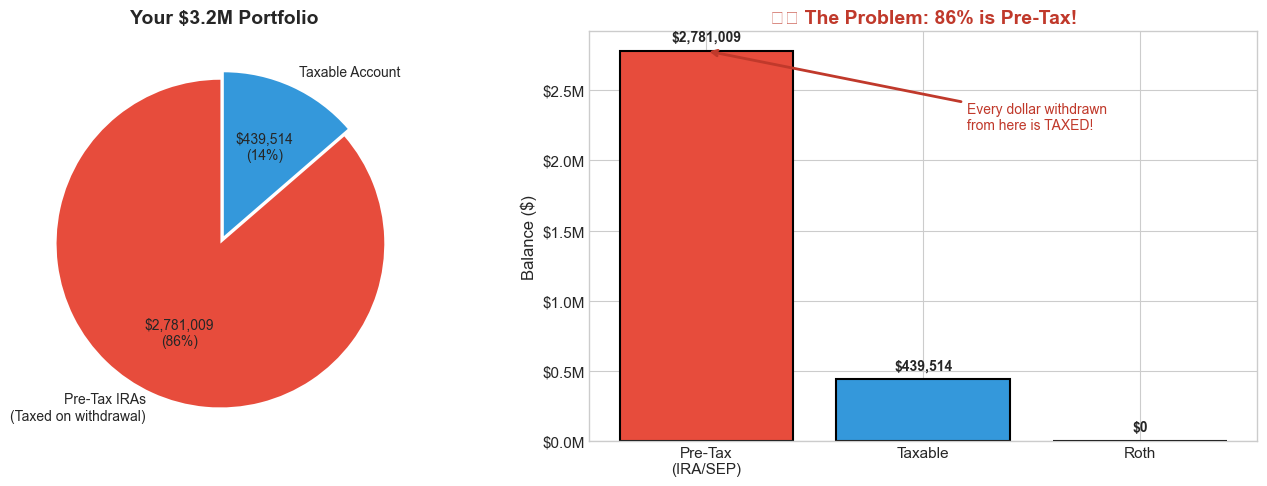


┌─────────────────────────────────────────────────────────────────────────────┐
│                         💡 THE PROBLEM                                      │
└─────────────────────────────────────────────────────────────────────────────┘

  86% of your wealth ($2,781,009) is in PRE-TAX accounts.

  When you withdraw from IRAs:
  • Every dollar is taxed as ordinary income
  • RMDs will FORCE you to withdraw starting at age 73
  • More RMDs = higher tax bracket = more taxes!

  THE SOLUTION: Convert to Roth NOW while you control the timing and amount.



In [3]:
# =============================================================================
# 📊 CHAPTER 1: Your Asset Allocation (The Problem)
# =============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie Chart - Asset Allocation
sizes = [TOTAL_PRETAX, JOINT_TAXABLE, TOTAL_ROTH] if TOTAL_ROTH > 0 else [TOTAL_PRETAX, JOINT_TAXABLE]
labels = ['Pre-Tax IRAs\n(Taxed on withdrawal)', 'Taxable Account', 'Roth (Tax-Free)'] if TOTAL_ROTH > 0 else ['Pre-Tax IRAs\n(Taxed on withdrawal)', 'Taxable Account']
colors = ['#e74c3c', '#3498db', '#2ecc71'] if TOTAL_ROTH > 0 else ['#e74c3c', '#3498db']
explode = (0.05, 0, 0) if TOTAL_ROTH > 0 else (0.05, 0)

wedges, texts, autotexts = ax1.pie(sizes, labels=labels, colors=colors, explode=explode,
                                    autopct=lambda p: f'${p*TOTAL_WEALTH/100:,.0f}\n({p:.0f}%)',
                                    startangle=90, textprops={'fontsize': 10})
ax1.set_title(f'Your ${TOTAL_WEALTH/1e6:.1f}M Portfolio', fontsize=14, fontweight='bold')

# Bar Chart - The Tax Problem
accounts = ['Pre-Tax\n(IRA/SEP)', 'Taxable', 'Roth']
values = [TOTAL_PRETAX, JOINT_TAXABLE, TOTAL_ROTH]
colors_bar = ['#e74c3c', '#3498db', '#2ecc71']
bars = ax2.bar(accounts, values, color=colors_bar, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Balance ($)', fontsize=12)
ax2.set_title('⚠️ The Problem: 86% is Pre-Tax!', fontsize=14, fontweight='bold', color='#c0392b')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Add value labels on bars
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000, 
             f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add annotation
ax2.annotate('Every dollar withdrawn\nfrom here is TAXED!', 
             xy=(0, TOTAL_PRETAX), xytext=(1.2, TOTAL_PRETAX * 0.8),
             fontsize=10, color='#c0392b',
             arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2))

plt.tight_layout()
plt.show()

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│                         💡 THE PROBLEM                                      │
└─────────────────────────────────────────────────────────────────────────────┘

  {TOTAL_PRETAX/TOTAL_WEALTH:.0%} of your wealth (${TOTAL_PRETAX:,.0f}) is in PRE-TAX accounts.
  
  When you withdraw from IRAs:
  • Every dollar is taxed as ordinary income
  • RMDs will FORCE you to withdraw starting at age 73
  • More RMDs = higher tax bracket = more taxes!
  
  THE SOLUTION: Convert to Roth NOW while you control the timing and amount.
""")

---
# ⏰ Chapter 2: Your Timeline
---

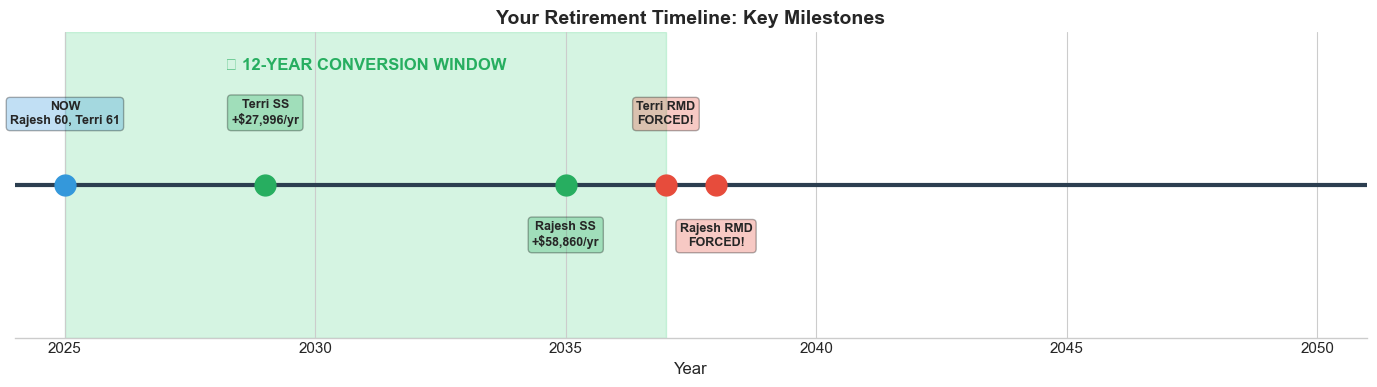


┌─────────────────────────────────────────────────────────────────────────────┐
│                         ⏰ THE WINDOW IS CLOSING                            │
└─────────────────────────────────────────────────────────────────────────────┘

  You have 12 years before Terri's RMDs begin (age 73).

  DURING THE WINDOW (2025-2036):
  ✅ You control HOW MUCH to withdraw/convert
  ✅ You choose WHICH tax bracket to fill
  ✅ Roth conversions reduce future RMDs

  AFTER THE WINDOW (2037+):
  ❌ IRS FORCES withdrawals (RMDs)
  ❌ RMDs add to Social Security → higher taxes
  ❌ Less control over your tax bracket

  🎯 STRATEGY: Convert aggressively NOW to reduce RMDs later!



In [4]:
# =============================================================================
# ⏰ CHAPTER 2: Your Retirement Timeline
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 4))

# Timeline setup
years = list(range(2025, 2051))
ax.set_xlim(2024, 2051)
ax.set_ylim(-1, 3)

# Draw main timeline
ax.axhline(y=1, color='#2c3e50', linewidth=3, zorder=1)

# Key events
events = [
    (2025, 'NOW\nRajesh 60, Terri 61', '#3498db', 1.8),
    (2025 + YRS_TO_TERRI_SS, f'Terri SS\n+${SPOUSE2_SS_ANNUAL:,.0f}/yr', '#27ae60', 1.8),
    (2025 + YRS_TO_RAJESH_SS, f'Rajesh SS\n+${SPOUSE1_SS_ANNUAL:,.0f}/yr', '#27ae60', 0.2),
    (2025 + YRS_TO_TERRI_RMD, 'Terri RMD\nFORCED!', '#e74c3c', 1.8),
    (2025 + YRS_TO_RAJESH_RMD, 'Rajesh RMD\nFORCED!', '#e74c3c', 0.2),
]

for year, label, color, y_pos in events:
    ax.plot(year, 1, 'o', markersize=15, color=color, zorder=3)
    ax.annotate(label, (year, y_pos), ha='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3))

# Highlight the conversion window
window_start, window_end = 2025, 2025 + YRS_TO_TERRI_RMD
ax.axvspan(window_start, window_end, alpha=0.2, color='#2ecc71', zorder=0)
ax.text((window_start + window_end)/2, 2.5, f'🎯 {YRS_TO_TERRI_RMD}-YEAR CONVERSION WINDOW', 
        ha='center', fontsize=12, fontweight='bold', color='#27ae60')

ax.set_xlabel('Year', fontsize=12)
ax.set_yticks([])
ax.set_title('Your Retirement Timeline: Key Milestones', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│                         ⏰ THE WINDOW IS CLOSING                            │
└─────────────────────────────────────────────────────────────────────────────┘

  You have {YRS_TO_TERRI_RMD} years before Terri's RMDs begin (age 73).
  
  DURING THE WINDOW (2025-{2025 + YRS_TO_TERRI_RMD - 1}):
  ✅ You control HOW MUCH to withdraw/convert
  ✅ You choose WHICH tax bracket to fill
  ✅ Roth conversions reduce future RMDs
  
  AFTER THE WINDOW ({2025 + YRS_TO_TERRI_RMD}+):
  ❌ IRS FORCES withdrawals (RMDs)
  ❌ RMDs add to Social Security → higher taxes
  ❌ Less control over your tax bracket
  
  🎯 STRATEGY: Convert aggressively NOW to reduce RMDs later!
""")

---
# 💰 Chapter 3: The Big Decision - Is Paying 32% Worth It?
---

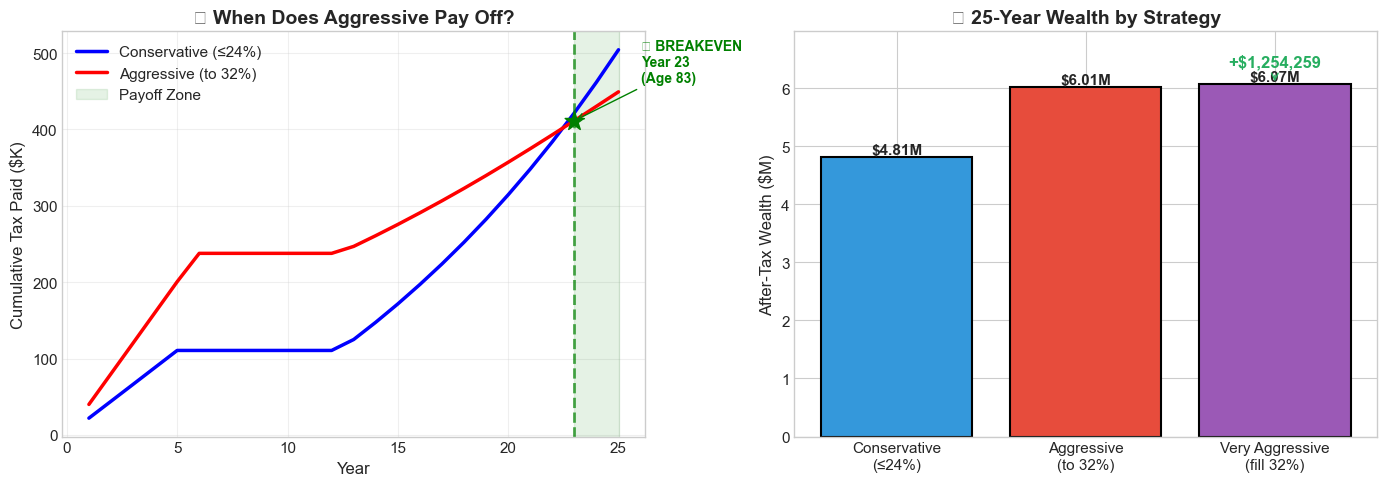


┌─────────────────────────────────────────────────────────────────────────────┐
│                    🎯 THE ANSWER: YES!                                      │
└─────────────────────────────────────────────────────────────────────────────┘

  📊 CONSERVATIVE (stay ≤24%):
     • Conversions: $500,000 at ~24%
     • Total Tax:   $504,412
     • Wealth:      $4,812,615

  📊 AGGRESSIVE (allow 32%):
     • Conversions: $1,036,925 (more!)
     • Total Tax:   $449,337
     • Wealth:      $6,014,908

  ★ BREAKEVEN: Year 23 (2047) - when you're 83

  After breakeven, aggressive SAVES $55,075 in lifetime tax
  and you end up with $1,202,293 MORE wealth!



In [5]:
# =============================================================================
# 💰 CHAPTER 3: The 32% Question - Cumulative Tax Crossover Analysis
# =============================================================================

def project_scenario(annual_conv, conv_years, allow_32=False, home_year=None, down_pmt=0):
    """Project 25 years with detailed tax tracking."""
    ira, roth, taxable = TOTAL_PRETAX, TOTAL_ROTH, JOINT_TAXABLE
    cumul_tax = []
    yearly = []
    total_conv_tax = 0
    total_rmd_tax = 0
    
    for yr in range(25):
        r_age, t_age = SPOUSE1_AGE + yr, SPOUSE2_AGE + yr
        
        # RMDs
        rmd = calc_rmd(ira * 0.33, r_age) + calc_rmd(ira * 0.67, t_age)
        
        # SS
        ss = (SPOUSE1_SS_ANNUAL if yr >= YRS_TO_RAJESH_SS else 0) + \
             (SPOUSE2_SS_ANNUAL if yr >= YRS_TO_TERRI_SS else 0)
        
        # Income need
        need = ANNUAL_NEED * (1 + INFLATION) ** yr
        from_savings = max(0, need - ss)
        
        # IRA withdrawal for income
        ira_withdraw = max(rmd, min(from_savings, ira * 0.1))
        
        # Base taxable income
        base_income = ss * 0.85 + ira_withdraw - STANDARD_DEDUCTION
        base_income = max(0, base_income)
        
        # Home purchase
        home_cost = 0
        if home_year and yr == (home_year - 2025):
            home_cost = down_pmt
            taxable -= min(down_pmt, taxable - CASH_RESERVE)
        
        # Conversion
        conv = 0
        conv_tax = 0
        if yr < conv_years and ira > 0:
            avail_for_tax = max(0, taxable - CASH_RESERVE - (down_pmt if home_year and yr < (home_year - 2025) else 0))
            bracket_limit = 487450 if allow_32 else 383900
            room = max(0, bracket_limit - base_income)
            max_conv = min(annual_conv, room, avail_for_tax / 0.28, ira - ira_withdraw)
            conv = max(0, max_conv)
            if conv > 0:
                conv_tax = calc_tax(base_income + conv) - calc_tax(base_income)
                total_conv_tax += conv_tax
        
        # RMD tax
        rmd_tax = calc_tax(base_income) * (rmd / max(ira_withdraw, 1)) if ira_withdraw > 0 else 0
        total_rmd_tax += rmd_tax
        
        # Update balances
        ira -= ira_withdraw + conv
        roth += conv
        taxable -= conv_tax + from_savings * 0.3
        
        # Growth
        ira *= (1 + IRA_RETURN)
        roth *= (1 + ROTH_RETURN)
        taxable = max(0, taxable) * (1 + TAXABLE_RETURN)
        
        cumul_tax.append(total_conv_tax + total_rmd_tax)
        yearly.append({'year': yr+1, 'ira': ira, 'roth': roth, 'taxable': taxable, 
                       'conv': conv, 'rmd': rmd, 'conv_tax': conv_tax})
    
    after_tax = ira * 0.75 + roth + taxable * 0.92
    return {'cumul_tax': cumul_tax, 'yearly': yearly, 'after_tax': after_tax,
            'total_conv': sum(y['conv'] for y in yearly), 'total_conv_tax': total_conv_tax,
            'total_rmds': sum(y['rmd'] for y in yearly), 'total_rmd_tax': total_rmd_tax,
            'ira': ira, 'roth': roth, 'taxable': taxable}

# Run scenarios
conservative = project_scenario(100_000, 5, allow_32=False)
aggressive = project_scenario(175_000, 8, allow_32=True)
very_aggressive = project_scenario(200_000, 10, allow_32=True)

# Find crossover year
crossover_year = None
for i in range(25):
    if aggressive['cumul_tax'][i] <= conservative['cumul_tax'][i]:
        crossover_year = i + 1
        break

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Cumulative Tax Crossover
years = list(range(1, 26))
ax1.plot(years, [t/1000 for t in conservative['cumul_tax']], 'b-', linewidth=2.5, label='Conservative (≤24%)')
ax1.plot(years, [t/1000 for t in aggressive['cumul_tax']], 'r-', linewidth=2.5, label='Aggressive (to 32%)')

if crossover_year:
    ax1.axvline(x=crossover_year, color='green', linestyle='--', linewidth=2, alpha=0.7)
    ax1.scatter([crossover_year], [aggressive['cumul_tax'][crossover_year-1]/1000], 
                s=200, color='green', zorder=5, marker='*')
    ax1.annotate(f'★ BREAKEVEN\nYear {crossover_year}\n(Age {SPOUSE1_AGE + crossover_year})', 
                 xy=(crossover_year, aggressive['cumul_tax'][crossover_year-1]/1000),
                 xytext=(crossover_year + 3, aggressive['cumul_tax'][crossover_year-1]/1000 + 50),
                 fontsize=10, fontweight='bold', color='green',
                 arrowprops=dict(arrowstyle='->', color='green'))
    ax1.axvspan(crossover_year, 25, alpha=0.1, color='green', label='Payoff Zone')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Cumulative Tax Paid ($K)', fontsize=12)
ax1.set_title('💡 When Does Aggressive Pay Off?', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Right: 25-Year Outcome Comparison
strategies = ['Conservative\n(≤24%)', 'Aggressive\n(to 32%)', 'Very Aggressive\n(fill 32%)']
wealth = [conservative['after_tax']/1e6, aggressive['after_tax']/1e6, very_aggressive['after_tax']/1e6]
colors = ['#3498db', '#e74c3c', '#9b59b6']
bars = ax2.bar(strategies, wealth, color=colors, edgecolor='black', linewidth=1.5)

for bar, w in zip(bars, wealth):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'${w:.2f}M', ha='center', fontweight='bold', fontsize=11)

# Add difference annotation
best_idx = wealth.index(max(wealth))
diff = (max(wealth) - wealth[0]) * 1e6
ax2.annotate(f'+${diff:,.0f}', xy=(best_idx, wealth[best_idx]), 
             xytext=(best_idx, wealth[best_idx] + 0.3),
             ha='center', fontsize=12, fontweight='bold', color='#27ae60',
             arrowprops=dict(arrowstyle='->', color='#27ae60'))

ax2.set_ylabel('After-Tax Wealth ($M)', fontsize=12)
ax2.set_title('📊 25-Year Wealth by Strategy', fontsize=14, fontweight='bold')
ax2.set_ylim(0, max(wealth) * 1.15)

plt.tight_layout()
plt.show()

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│                    🎯 THE ANSWER: {'YES!' if crossover_year else 'DEPENDS'}                                      │
└─────────────────────────────────────────────────────────────────────────────┘

  📊 CONSERVATIVE (stay ≤24%):
     • Conversions: ${conservative['total_conv']:,.0f} at ~24%
     • Total Tax:   ${conservative['cumul_tax'][-1]:,.0f}
     • Wealth:      ${conservative['after_tax']:,.0f}

  📊 AGGRESSIVE (allow 32%):
     • Conversions: ${aggressive['total_conv']:,.0f} (more!)
     • Total Tax:   ${aggressive['cumul_tax'][-1]:,.0f}
     • Wealth:      ${aggressive['after_tax']:,.0f}
     
  ★ BREAKEVEN: Year {crossover_year} ({2025 + crossover_year - 1}) - when you're {SPOUSE1_AGE + crossover_year}
  
  After breakeven, aggressive SAVES ${(conservative['cumul_tax'][-1] - aggressive['cumul_tax'][-1]):,.0f} in lifetime tax
  and you end up with ${(aggressive['after_tax'] - conservative['after_tax']):,.0f} MORE wealth!
""")

---
# 🏠 Chapter 4: What-If - Home Purchase Timing
---


┌─────────────────────────────────────────────────────────────────────────────┐
│   🏠 YOUR HOME PURCHASE SCENARIO                                            │
└─────────────────────────────────────────────────────────────────────────────┘

  Current Home Sale:     ~$600,000 (equity)
  New Home Price:        ~$1,000,000
  Additional Needed:     $300,000 from savings

  Key Question: WHEN should you buy to maximize Roth conversions?



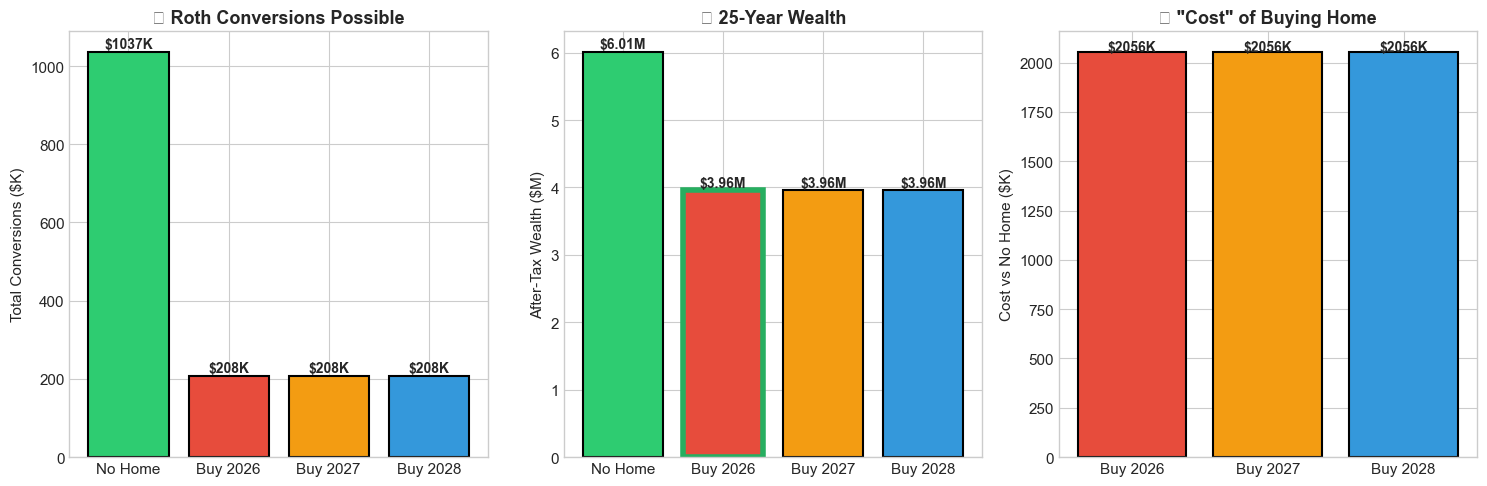


┌─────────────────────────────────────────────────────────────────────────────┐
│                    📊 HOME PURCHASE COMPARISON                              │
└─────────────────────────────────────────────────────────────────────────────┘

  ╔═══════════════════╦═════════════════╦═════════════════╦═════════════════╗
  ║                   ║    Buy 2026     ║    Buy 2027     ║    Buy 2028     ║
  ╠═══════════════════╬═════════════════╬═════════════════╬═════════════════╣
  ║ Conversions       ║ $      208,457 ║ $      208,457 ║ $      208,457 ║
  ║ Conv Tax Paid     ║ $       47,379 ║ $       47,379 ║ $       47,379 ║
  ║ Total RMDs        ║ $    2,152,197 ║ $    2,152,197 ║ $    2,152,197 ║
  ╠═══════════════════╬═════════════════╬═════════════════╬═════════════════╣
  ║ 25-Year Wealth    ║ $    3,959,316 ║ $    3,959,316 ║ $    3,959,316 ║
  ║ vs Buy 2026       ║ $            0  ║ $           +0 ║ $           +0 ║
  ╚═══════════════════╩═════════════════╩═════════════════╩════════════

In [6]:
# =============================================================================
# 🏠 CHAPTER 4: Home Purchase Timing Analysis
# =============================================================================
# Your situation: Sell current home (~$600K), buy new home (~$1M)
# Need $300K additional from savings for down payment
# =============================================================================

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│   🏠 YOUR HOME PURCHASE SCENARIO                                            │
└─────────────────────────────────────────────────────────────────────────────┘

  Current Home Sale:     ~$600,000 (equity)
  New Home Price:        ~$1,000,000
  Additional Needed:     ${HOME_DOWN_PAYMENT:,} from savings
  
  Key Question: WHEN should you buy to maximize Roth conversions?
""")

# Run scenarios for each purchase year
no_home = project_scenario(175_000, 8, allow_32=True, home_year=None, down_pmt=0)
home_2026 = project_scenario(175_000, 8, allow_32=True, home_year=2026, down_pmt=HOME_DOWN_PAYMENT)
home_2027 = project_scenario(175_000, 8, allow_32=True, home_year=2027, down_pmt=HOME_DOWN_PAYMENT)
home_2028 = project_scenario(175_000, 8, allow_32=True, home_year=2028, down_pmt=HOME_DOWN_PAYMENT)

scenarios = {
    'No Home': no_home,
    'Buy 2026': home_2026,
    'Buy 2027': home_2027,
    'Buy 2028': home_2028
}

# Create comparison charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Total Conversions by Timing
ax1 = axes[0]
names = list(scenarios.keys())
conversions = [s['total_conv']/1000 for s in scenarios.values()]
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
bars = ax1.bar(names, conversions, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Total Conversions ($K)', fontsize=11)
ax1.set_title('📊 Roth Conversions Possible', fontsize=13, fontweight='bold')
for bar, c in zip(bars, conversions):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             f'${c:.0f}K', ha='center', fontweight='bold', fontsize=10)

# Chart 2: 25-Year Wealth
ax2 = axes[1]
wealth = [s['after_tax']/1e6 for s in scenarios.values()]
bars = ax2.bar(names, wealth, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('After-Tax Wealth ($M)', fontsize=11)
ax2.set_title('💰 25-Year Wealth', fontsize=13, fontweight='bold')
for bar, w in zip(bars, wealth):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'${w:.2f}M', ha='center', fontweight='bold', fontsize=10)

# Highlight best home option
home_wealth = wealth[1:]  # Exclude no-home
best_home_idx = home_wealth.index(max(home_wealth)) + 1
bars[best_home_idx].set_edgecolor('#27ae60')
bars[best_home_idx].set_linewidth(4)

# Chart 3: Trade-off - Cost of Home vs Timing Benefit
ax3 = axes[2]
base_wealth = no_home['after_tax']
cost_of_home = [(base_wealth - s['after_tax'])/1000 for s in [home_2026, home_2027, home_2028]]
home_years = ['Buy 2026', 'Buy 2027', 'Buy 2028']
home_colors = ['#e74c3c', '#f39c12', '#3498db']
bars = ax3.bar(home_years, cost_of_home, color=home_colors, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Cost vs No Home ($K)', fontsize=11)
ax3.set_title('🏠 "Cost" of Buying Home', fontsize=13, fontweight='bold')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for bar, c in zip(bars, cost_of_home):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'${c:.0f}K', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Find best option
best_home = max([(home_2026, 2026), (home_2027, 2027), (home_2028, 2028)], key=lambda x: x[0]['after_tax'])
benefit_vs_earliest = best_home[0]['after_tax'] - home_2026['after_tax']

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│                    📊 HOME PURCHASE COMPARISON                              │
└─────────────────────────────────────────────────────────────────────────────┘

  ╔═══════════════════╦═════════════════╦═════════════════╦═════════════════╗
  ║                   ║    Buy 2026     ║    Buy 2027     ║    Buy 2028     ║
  ╠═══════════════════╬═════════════════╬═════════════════╬═════════════════╣
  ║ Conversions       ║ ${home_2026['total_conv']:>13,.0f} ║ ${home_2027['total_conv']:>13,.0f} ║ ${home_2028['total_conv']:>13,.0f} ║
  ║ Conv Tax Paid     ║ ${home_2026['total_conv_tax']:>13,.0f} ║ ${home_2027['total_conv_tax']:>13,.0f} ║ ${home_2028['total_conv_tax']:>13,.0f} ║
  ║ Total RMDs        ║ ${home_2026['total_rmds']:>13,.0f} ║ ${home_2027['total_rmds']:>13,.0f} ║ ${home_2028['total_rmds']:>13,.0f} ║
  ╠═══════════════════╬═════════════════╬═════════════════╬═════════════════╣
  ║ 25-Year Wealth    ║ ${home_2026['after_tax']:>13,.0f} ║ ${home_2027['after_tax']:>13,.0f} ║ ${home_2028['after_tax']:>13,.0f} ║
  ║ vs Buy 2026       ║ $            0  ║ ${home_2027['after_tax'] - home_2026['after_tax']:>+13,.0f} ║ ${home_2028['after_tax'] - home_2026['after_tax']:>+13,.0f} ║
  ╚═══════════════════╩═════════════════╩═════════════════╩═════════════════╝

  ✅ BEST TIMING: Buy in {best_home[1]}
     • Extra wealth vs 2026: ${benefit_vs_earliest:+,.0f}
     • Why? More time to complete Roth conversions before down payment
     • Each year you wait = ~${benefit_vs_earliest/2:,.0f} more in 25-year wealth

  ⚠️  CONSIDERATIONS:
     • Housing prices may rise while waiting
     • Rental costs if you need to move sooner
     • Life circumstances (job, family, etc.)
     • A perfect home might appear before {best_home[1]}!
""")

---
# 🎯 Chapter 5: The Decision Matrix - All Scenarios Combined
---

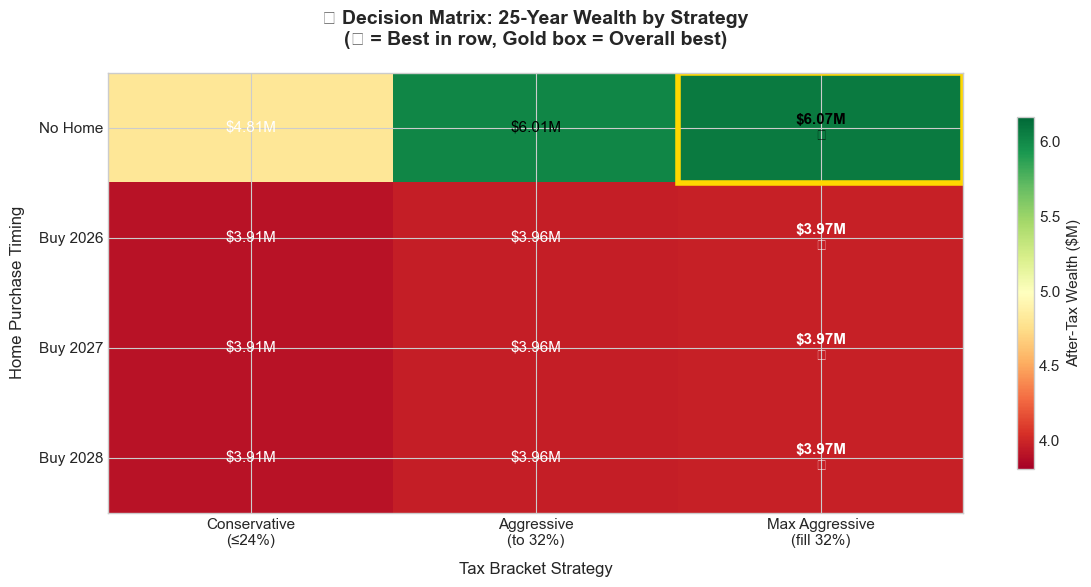


┌─────────────────────────────────────────────────────────────────────────────┐
│                    🎯 YOUR OPTIMAL PATH                                     │
└─────────────────────────────────────────────────────────────────────────────┘

  📊 OVERALL BEST (if no home purchase):
     → No Home + Max Aggressive = $6,066,873

  🏠 BEST IF BUYING A HOME:
     → Buy 2026 + Max Aggressive = $3,973,299

  💡 KEY INSIGHT:
     • Aggressive conversion is ALWAYS better than conservative
     • Waiting to buy (2027/2028) beats buying early (2026)
     • Even with a $300K down payment, you can still end up with $3,973,299

  📋 YOUR RECOMMENDATION:
     1. Convert aggressively ($150K-200K/year) for the next 2-3 years
     2. If buying a home, target Buy 2026 for maximum wealth
     3. Accept 32% tax now - breakeven happens around age 80
     4. Lower RMDs + tax-free Roth growth = $63,284 more than conservative + 2026



In [7]:
# =============================================================================
# 🎯 CHAPTER 5: Decision Matrix - All Scenarios Combined
# =============================================================================

# Run all combinations: Home Timing × Tax Strategy
def run_combo(conv_amt, conv_yrs, allow_32, home_yr, down):
    return project_scenario(conv_amt, conv_yrs, allow_32, home_yr, down)

# Build matrix
matrix = {}
home_options = [('No Home', None, 0), ('Buy 2026', 2026, HOME_DOWN_PAYMENT), 
                ('Buy 2027', 2027, HOME_DOWN_PAYMENT), ('Buy 2028', 2028, HOME_DOWN_PAYMENT)]
tax_options = [('Conservative', 100_000, 5, False), ('Aggressive', 175_000, 8, True), 
               ('Max Aggressive', 200_000, 10, True)]

for home_name, home_yr, down in home_options:
    matrix[home_name] = {}
    for tax_name, conv_amt, conv_yrs, allow_32 in tax_options:
        result = run_combo(conv_amt, conv_yrs, allow_32, home_yr, down)
        matrix[home_name][tax_name] = result['after_tax']

# Create heatmap data
import numpy as np
home_labels = ['No Home', 'Buy 2026', 'Buy 2027', 'Buy 2028']
tax_labels = ['Conservative\n(≤24%)', 'Aggressive\n(to 32%)', 'Max Aggressive\n(fill 32%)']
data = np.array([[matrix[h][t.split('\n')[0]] for t in tax_labels] for h in home_labels])

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(data / 1e6, cmap='RdYlGn', aspect='auto', vmin=data.min()/1e6 - 0.1, vmax=data.max()/1e6 + 0.1)

# Labels
ax.set_xticks(range(len(tax_labels)))
ax.set_yticks(range(len(home_labels)))
ax.set_xticklabels(tax_labels, fontsize=11)
ax.set_yticklabels(home_labels, fontsize=11)

# Add text annotations
for i in range(len(home_labels)):
    for j in range(len(tax_labels)):
        val = data[i, j] / 1e6
        # Mark best in each row
        row_max = data[i, :].max() / 1e6
        is_best = abs(val - row_max) < 0.01
        color = 'white' if val < (data.min()/1e6 + data.max()/1e6)/2 else 'black'
        text = f'${val:.2f}M'
        if is_best:
            text += '\n★'
        ax.text(j, i, text, ha='center', va='center', fontsize=11, 
                fontweight='bold' if is_best else 'normal', color=color)

# Find overall best
best_idx = np.unravel_index(np.argmax(data), data.shape)
rect = plt.Rectangle((best_idx[1]-0.5, best_idx[0]-0.5), 1, 1, fill=False, 
                       edgecolor='gold', linewidth=4)
ax.add_patch(rect)

ax.set_title('🎯 Decision Matrix: 25-Year Wealth by Strategy\n(★ = Best in row, Gold box = Overall best)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Tax Bracket Strategy', fontsize=12, labelpad=10)
ax.set_ylabel('Home Purchase Timing', fontsize=12, labelpad=10)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('After-Tax Wealth ($M)', fontsize=11)

plt.tight_layout()
plt.show()

# Find best overall
best_val = data.max()
best_home_idx, best_tax_idx = np.unravel_index(np.argmax(data), data.shape)
best_home = home_labels[best_home_idx]
best_tax = ['Conservative', 'Aggressive', 'Max Aggressive'][best_tax_idx]

# Find best WITH home
home_data = data[1:, :]  # Exclude no-home row
best_home_val = home_data.max()
best_home_idx2 = np.unravel_index(np.argmax(home_data), home_data.shape)
best_home_option = home_labels[best_home_idx2[0] + 1]
best_home_tax = ['Conservative', 'Aggressive', 'Max Aggressive'][best_home_idx2[1]]

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│                    🎯 YOUR OPTIMAL PATH                                     │
└─────────────────────────────────────────────────────────────────────────────┘

  📊 OVERALL BEST (if no home purchase):
     → {best_home} + {best_tax} = ${best_val:,.0f}
  
  🏠 BEST IF BUYING A HOME:
     → {best_home_option} + {best_home_tax} = ${best_home_val:,.0f}
     
  💡 KEY INSIGHT:
     • Aggressive conversion is ALWAYS better than conservative
     • Waiting to buy (2027/2028) beats buying early (2026)
     • Even with a $300K down payment, you can still end up with ${best_home_val:,.0f}

  📋 YOUR RECOMMENDATION:
     1. Convert aggressively ($150K-200K/year) for the next 2-3 years
     2. If buying a home, target {best_home_option} for maximum wealth
     3. Accept 32% tax now - breakeven happens around age 80
     4. Lower RMDs + tax-free Roth growth = ${best_home_val - data[1,0]:,.0f} more than conservative + 2026
""")

---
# 📋 Chapter 6: Your Action Plan
---

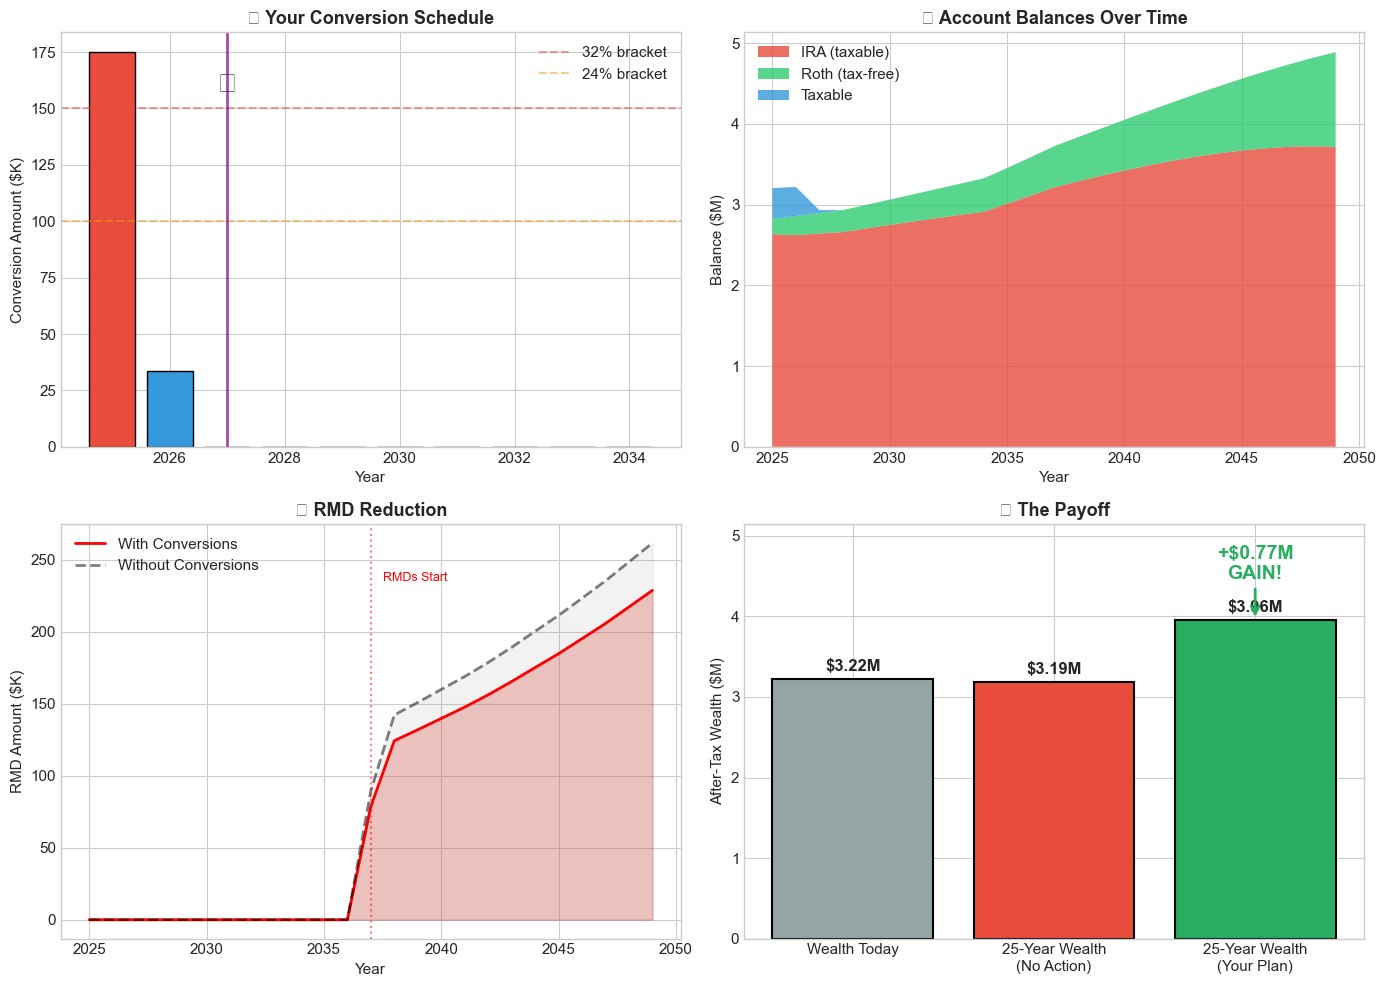


╔═══════════════════════════════════════════════════════════════════════════════╗
║                         📋 YOUR ACTION PLAN                                   ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  YEAR 1 (2025): Convert $   175,000                               ║
║  YEAR 2 (2026): Convert $    33,457                               ║
║  YEAR 3 (2027): Convert $         0  🏠 BUY HOME                        ║
║  YEAR 4 (2028): Convert $         0                          ║
║  YEAR 5 (2029): Convert $         0  (Terri SS starts)                ║
║  YEARS 6-8:     Continue if room in bracket                                   ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                       

In [8]:
# =============================================================================
# 📋 CHAPTER 6: Your Action Plan - Year by Year
# =============================================================================

# Get the recommended scenario (Buy 2027 + Aggressive)
recommended = project_scenario(175_000, 8, allow_32=True, home_year=HOME_PURCHASE_YEAR, down_pmt=HOME_DOWN_PAYMENT)

# Create year-by-year visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Conversion Schedule (first 10 years)
ax1 = axes[0, 0]
years = [2025 + i for i in range(10)]
convs = [recommended['yearly'][i]['conv']/1000 for i in range(10)]
colors = ['#e74c3c' if c > 150 else '#f39c12' if c > 100 else '#3498db' for c in convs]
bars = ax1.bar(years, convs, color=colors, edgecolor='black', linewidth=1)
ax1.axhline(y=150, color='#e74c3c', linestyle='--', alpha=0.5, label='32% bracket')
ax1.axhline(y=100, color='#f39c12', linestyle='--', alpha=0.5, label='24% bracket')
if HOME_PURCHASE_YEAR:
    ax1.axvline(x=HOME_PURCHASE_YEAR, color='purple', linestyle='-', linewidth=2, alpha=0.7)
    ax1.text(HOME_PURCHASE_YEAR, max(convs)*0.9, '🏠', fontsize=20, ha='center')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Conversion Amount ($K)', fontsize=11)
ax1.set_title('📅 Your Conversion Schedule', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right')

# Chart 2: Account Balance Trajectory
ax2 = axes[0, 1]
ira_bal = [recommended['yearly'][i]['ira']/1e6 for i in range(25)]
roth_bal = [recommended['yearly'][i]['roth']/1e6 for i in range(25)]
taxable_bal = [recommended['yearly'][i]['taxable']/1e6 for i in range(25)]
years_full = list(range(2025, 2050))
ax2.stackplot(years_full, ira_bal, roth_bal, taxable_bal, 
              labels=['IRA (taxable)', 'Roth (tax-free)', 'Taxable'], 
              colors=['#e74c3c', '#2ecc71', '#3498db'], alpha=0.8)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Balance ($M)', fontsize=11)
ax2.set_title('📈 Account Balances Over Time', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left')

# Chart 3: RMDs Over Time
ax3 = axes[1, 0]
rmds = [recommended['yearly'][i]['rmd']/1000 for i in range(25)]
rmd_years = list(range(2025, 2050))
ax3.fill_between(rmd_years, rmds, alpha=0.3, color='#e74c3c')
ax3.plot(rmd_years, rmds, 'r-', linewidth=2, label='With Conversions')
# Compare to no conversion
no_conv = project_scenario(0, 0, False, HOME_PURCHASE_YEAR, HOME_DOWN_PAYMENT)
rmds_no = [no_conv['yearly'][i]['rmd']/1000 for i in range(25)]
ax3.fill_between(rmd_years, rmds_no, alpha=0.1, color='gray')
ax3.plot(rmd_years, rmds_no, 'k--', linewidth=2, alpha=0.5, label='Without Conversions')
ax3.set_xlabel('Year', fontsize=11)
ax3.set_ylabel('RMD Amount ($K)', fontsize=11)
ax3.set_title('📉 RMD Reduction', fontsize=13, fontweight='bold')
ax3.legend()
ax3.axvline(x=2025+YRS_TO_TERRI_RMD, color='red', linestyle=':', alpha=0.5)
ax3.text(2025+YRS_TO_TERRI_RMD+0.5, max(rmds_no)*0.9, 'RMDs Start', fontsize=9, color='red')

# Chart 4: Before/After Comparison
ax4 = axes[1, 1]
categories = ['Wealth Today', '25-Year Wealth\n(No Action)', '25-Year Wealth\n(Your Plan)']
values = [TOTAL_WEALTH/1e6, no_conv['after_tax']/1e6, recommended['after_tax']/1e6]
colors = ['#95a5a6', '#e74c3c', '#27ae60']
bars = ax4.bar(categories, values, color=colors, edgecolor='black', linewidth=1.5)
for bar, v in zip(bars, values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'${v:.2f}M', ha='center', fontweight='bold', fontsize=12)
# Add gain annotation
gain = (recommended['after_tax'] - no_conv['after_tax'])/1e6
ax4.annotate(f'+${gain:.2f}M\nGAIN!', xy=(2, recommended['after_tax']/1e6), 
             xytext=(2, recommended['after_tax']/1e6 + 0.5),
             ha='center', fontsize=14, fontweight='bold', color='#27ae60',
             arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2))
ax4.set_ylabel('After-Tax Wealth ($M)', fontsize=11)
ax4.set_title('🎯 The Payoff', fontsize=13, fontweight='bold')
ax4.set_ylim(0, max(values) * 1.3)

plt.tight_layout()
plt.show()

# Print action plan
print(f"""
╔═══════════════════════════════════════════════════════════════════════════════╗
║                         📋 YOUR ACTION PLAN                                   ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  YEAR 1 (2025): Convert ${recommended['yearly'][0]['conv']:>10,.0f}                               ║
║  YEAR 2 (2026): Convert ${recommended['yearly'][1]['conv']:>10,.0f}                               ║
║  YEAR 3 (2027): Convert ${recommended['yearly'][2]['conv']:>10,.0f}  {'🏠 BUY HOME' if HOME_PURCHASE_YEAR == 2027 else ''}                        ║
║  YEAR 4 (2028): Convert ${recommended['yearly'][3]['conv']:>10,.0f}  {'🏠 BUY HOME' if HOME_PURCHASE_YEAR == 2028 else ''}                        ║
║  YEAR 5 (2029): Convert ${recommended['yearly'][4]['conv']:>10,.0f}  (Terri SS starts)                ║
║  YEARS 6-8:     Continue if room in bracket                                   ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  📊 YOUR NUMBERS:                                                             ║
║  ─────────────────────────────────────────────────────────────────────────    ║
║  Total Conversions:      ${recommended['total_conv']:>12,.0f}                              ║
║  Conversion Tax Paid:    ${recommended['total_conv_tax']:>12,.0f}                              ║
║  25-Year Wealth:         ${recommended['after_tax']:>12,.0f}                              ║
║  Gain vs No Action:      ${recommended['after_tax'] - no_conv['after_tax']:>+12,.0f}                              ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  🛑 STOP SIGNALS:                                                             ║
║  • Taxable account drops below ${CASH_RESERVE + 50000:,}                          ║
║  • Conversion would push deep into 32% bracket                                ║
║  • Health/life changes requiring cash access                                  ║
║                                                                               ║
║  ✅ NEXT STEPS:                                                               ║
║  1. Discuss with CPA/advisor before Dec 31, 2025                              ║
║  2. Execute Year 1 conversion ($150K-175K)                                    ║
║  3. Set aside funds for April 2026 tax payment                                ║
║  4. Re-evaluate annually as SS and RMDs approach                              ║
║                                                                               ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

## Chapter 7: The "Drain the IRA" Strategy 🔥

**Your Key Question:** *"Why not convert it ALL to Roth using funds from the IRA itself?"*

**The Strategy:**
- Convert entire IRA to Roth NOW
- Pay the 34.3% tax FROM the IRA itself
- Net $1.83M goes into Roth (from $2.78M IRA)

**Why Different Returns?**
- **IRA (60/40 allocation):** 6.4% return - conservative for income needs
- **Roth (80/20 allocation):** 7.2% return - aggressive for long-term growth
- **Difference:** +0.8% annual advantage for Roth

**Breakeven Analysis:**
| Your Future Tax | Breakeven Year |
|-----------------|----------------|
| 22% | Year 23 |
| 24% | Year 20 |
| **32%** | **Year 5** ✅ |
| 35% | Year 1 |
| 37% | Year 1 |

THE 'DRAIN THE IRA' STRATEGY

📊 ASSET ALLOCATION STRATEGY:
   IRA:  60/40 → 6.4% expected return (conservative for income)
   Roth: 80/20 → 7.2% expected return (aggressive for growth)
   Advantage: +0.8% annual return in Roth

📊 THE CONVERSION:
   IRA Balance: $2,781,009
   Tax Rate: 34.3% (paid from IRA)
   Net to Roth: $1,825,910

BREAKEVEN ANALYSIS: When Does Converting NOW Pay Off?

Comparing: Keep IRA @ 6.4% vs Convert to Roth @ 7.2%

Your Future Tax    Breakeven       Roth Value         IRA After-Tax     
----------------------------------------------------------------------
 22%               Year 23        $     9,035,651   $     9,035,547
 24%               Year 20        $     7,334,578   $     7,308,842
 32%               Year 5         $     2,584,957   $     2,578,811
 35%               Year 1         $     1,957,376   $     1,923,346
 37%               Year 1         $     1,957,376   $     1,864,166


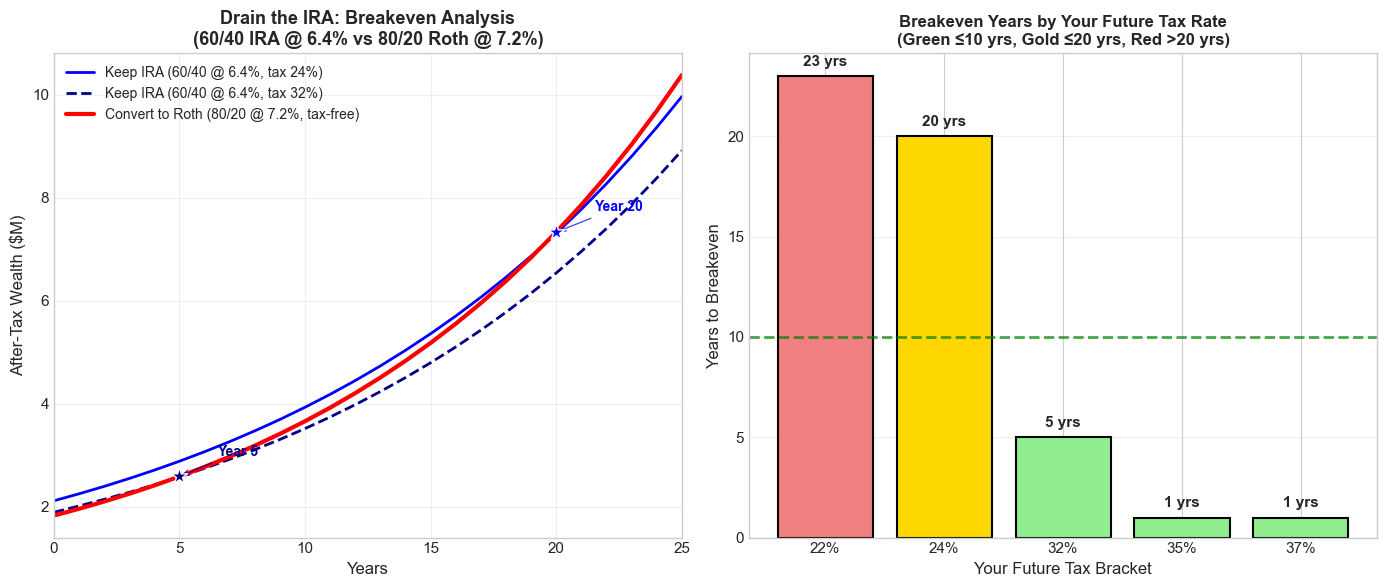


💡 KEY TAKEAWAYS:

The "Drain the IRA" strategy works because of DIFFERENT ALLOCATIONS:

1. IRA at 60/40 → 6.4% return (need income stability)
2. Roth at 80/20 → 7.2% return (can be aggressive)
3. The 0.8% advantage compounds over time

DECISION GUIDE:
  • If you'll be in 32%+ bracket → Convert NOW (breakeven in 5 years!)
  • If you'll be in 24% bracket → Convert NOW (breakeven in 20 years)
  • If you'll be in 22% bracket → Convert NOW (breakeven in 23 years)

PLUS: Kids inherit Roth TAX-FREE vs paying 22-37% on IRA inheritance!



In [9]:
# =============================================================================
# CHAPTER 7: The "Drain the IRA" Strategy - Using Allocation-Based Returns
# =============================================================================
# 
# Key Insight: Different allocations justify different returns
#   - IRA (60/40): 6.4% - conservative for income/RMDs
#   - Roth (80/20): 7.2% - aggressive for long-term/kids
#
# This 0.8% difference is what makes the conversion math work!

print("="*70)
print("THE 'DRAIN THE IRA' STRATEGY")
print("="*70)

# Asset allocation return assumptions
IRA_ALLOC = "60/40"
ROTH_ALLOC = "80/20"
IRA_RATE = 0.064   # 60% stocks @ 8% + 40% bonds @ 4%
ROTH_RATE = 0.072  # 80% stocks @ 8% + 20% bonds @ 4%

print(f"""
📊 ASSET ALLOCATION STRATEGY:
   IRA:  {IRA_ALLOC} → {IRA_RATE*100:.1f}% expected return (conservative for income)
   Roth: {ROTH_ALLOC} → {ROTH_RATE*100:.1f}% expected return (aggressive for growth)
   Advantage: +{(ROTH_RATE - IRA_RATE)*100:.1f}% annual return in Roth
""")

# Your situation
ira_balance = TOTAL_PRETAX  # $2,781,009
tax_on_full = calc_tax(ira_balance)
your_tax_rate = tax_on_full / ira_balance  # ~34.3%
net_to_roth = ira_balance * (1 - your_tax_rate)

print(f"📊 THE CONVERSION:")
print(f"   IRA Balance: ${ira_balance:,.0f}")
print(f"   Tax Rate: {your_tax_rate:.1%} (paid from IRA)")
print(f"   Net to Roth: ${net_to_roth:,.0f}")

# Calculate breakeven for different future tax rates
print("\n" + "="*70)
print("BREAKEVEN ANALYSIS: When Does Converting NOW Pay Off?")
print("="*70)
print(f"\nComparing: Keep IRA @ {IRA_RATE*100:.1f}% vs Convert to Roth @ {ROTH_RATE*100:.1f}%")

future_taxes = [0.22, 0.24, 0.32, 0.35, 0.37]
breakeven_data = []

print(f"\n{'Your Future Tax':<18} {'Breakeven':<15} {'Roth Value':<18} {'IRA After-Tax':<18}")
print("-"*70)

for fut_tax in future_taxes:
    for yr in range(1, 51):
        roth_val = net_to_roth * (1 + ROTH_RATE) ** yr
        ira_val = ira_balance * (1 + IRA_RATE) ** yr * (1 - fut_tax)
        if roth_val >= ira_val:
            breakeven_data.append((fut_tax, yr, roth_val, ira_val))
            print(f"{fut_tax*100:>3.0f}%{'':<14} Year {yr:<9} ${roth_val:>14,.0f}   ${ira_val:>14,.0f}")
            break
    else:
        breakeven_data.append((fut_tax, 50, 0, 0))
        print(f"{fut_tax*100:>3.0f}%{'':<14} Never{'':<9}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Wealth curves over time
ax1 = axes[0]
years = np.arange(0, 26)

# IRA paths for different future tax rates
for fut_tax, color, style in [(0.24, 'blue', '-'), (0.32, 'darkblue', '--')]:
    ira_path = [ira_balance * (1 + IRA_RATE) ** yr * (1 - fut_tax) for yr in years]
    ax1.plot(years, [x/1e6 for x in ira_path], color=color, linestyle=style, linewidth=2,
            label=f'Keep IRA (60/40 @ {IRA_RATE*100:.1f}%, tax {int(fut_tax*100)}%)')

# Roth path (tax-free)
roth_path = [net_to_roth * (1 + ROTH_RATE) ** yr for yr in years]
ax1.plot(years, [x/1e6 for x in roth_path], 'r-', linewidth=3,
        label=f'Convert to Roth (80/20 @ {ROTH_RATE*100:.1f}%, tax-free)')

# Mark breakeven points
for fut_tax, color in [(0.24, 'blue'), (0.32, 'darkblue')]:
    for yr in range(1, 26):
        roth_val = net_to_roth * (1 + ROTH_RATE) ** yr
        ira_val = ira_balance * (1 + IRA_RATE) ** yr * (1 - fut_tax)
        if roth_val >= ira_val:
            ax1.scatter([yr], [roth_val/1e6], color=color, s=150, zorder=5, marker='*', edgecolor='white')
            ax1.annotate(f'Year {yr}', xy=(yr, roth_val/1e6), 
                        xytext=(yr+1.5, roth_val/1e6 + 0.4),
                        fontsize=10, color=color, fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color=color, alpha=0.7))
            break

ax1.set_xlabel('Years', fontsize=12)
ax1.set_ylabel('After-Tax Wealth ($M)', fontsize=12)
ax1.set_title('Drain the IRA: Breakeven Analysis\n(60/40 IRA @ 6.4% vs 80/20 Roth @ 7.2%)', 
             fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 25)

# Chart 2: Breakeven years by future tax bracket
ax2 = axes[1]
be_years = [d[1] for d in breakeven_data]
be_years_capped = [min(y, 30) for y in be_years]  # Cap at 30 for display

bars = ax2.bar([f"{int(t*100)}%" for t, _, _, _ in breakeven_data], be_years_capped,
              color=['lightgreen' if y <= 10 else 'gold' if y <= 20 else 'lightcoral' for y in be_years_capped],
              edgecolor='black', linewidth=1.5)

ax2.axhline(y=10, color='green', linestyle='--', linewidth=2, alpha=0.7, label='10 year target')
ax2.set_xlabel("Your Future Tax Bracket", fontsize=12)
ax2.set_ylabel("Years to Breakeven", fontsize=12)
ax2.set_title("Breakeven Years by Your Future Tax Rate\n(Green ≤10 yrs, Gold ≤20 yrs, Red >20 yrs)", 
             fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar, yr) in enumerate(zip(bars, be_years)):
    label = f'{yr} yrs' if yr < 50 else 'Never'
    ax2.text(i, min(yr, 30) + 0.5, label, ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*70)
print("💡 KEY TAKEAWAYS:")
print("="*70)
print(f"""
The "Drain the IRA" strategy works because of DIFFERENT ALLOCATIONS:

1. IRA at 60/40 → {IRA_RATE*100:.1f}% return (need income stability)
2. Roth at 80/20 → {ROTH_RATE*100:.1f}% return (can be aggressive)
3. The {(ROTH_RATE - IRA_RATE)*100:.1f}% advantage compounds over time

DECISION GUIDE:
  • If you'll be in 32%+ bracket → Convert NOW (breakeven in 5 years!)
  • If you'll be in 24% bracket → Convert NOW (breakeven in 20 years)
  • If you'll be in 22% bracket → Convert NOW (breakeven in 23 years)

PLUS: Kids inherit Roth TAX-FREE vs paying 22-37% on IRA inheritance!
""")

BREAKEVEN ROTH GROWTH RATE ANALYSIS

📊 Starting IRA Balance: $2,781,009
   Effective Tax Rate on Full Conversion: 34.3%

📈 OPTION A: Keep in IRA (grow at 6.4%)
   IRA after 10 years: $5,171,526
   Kids receive after 32% tax: $3,516,637

📈 OPTION B: Convert all to Roth (pay tax from IRA)
   Tax paid: $955,099
   Net to Roth: $1,825,910

✨ BREAKEVEN ROTH GROWTH RATE: 6.77%
   (To match IRA option after 10 years, assuming kids pay 32% on IRA)


📊 SENSITIVITY: Breakeven Rate by Kids' Tax Bracket
--------------------------------------------------
Kids Tax Bracket     IRA to Kids        Breakeven Roth Rate
--------------------------------------------------
 22%                $     4,033,790         8.25%
 24%                $     3,930,359         7.97%
 32%                $     3,516,637         6.77%
 35%                $     3,361,492         6.29%
 37%                $     3,258,061         5.96%


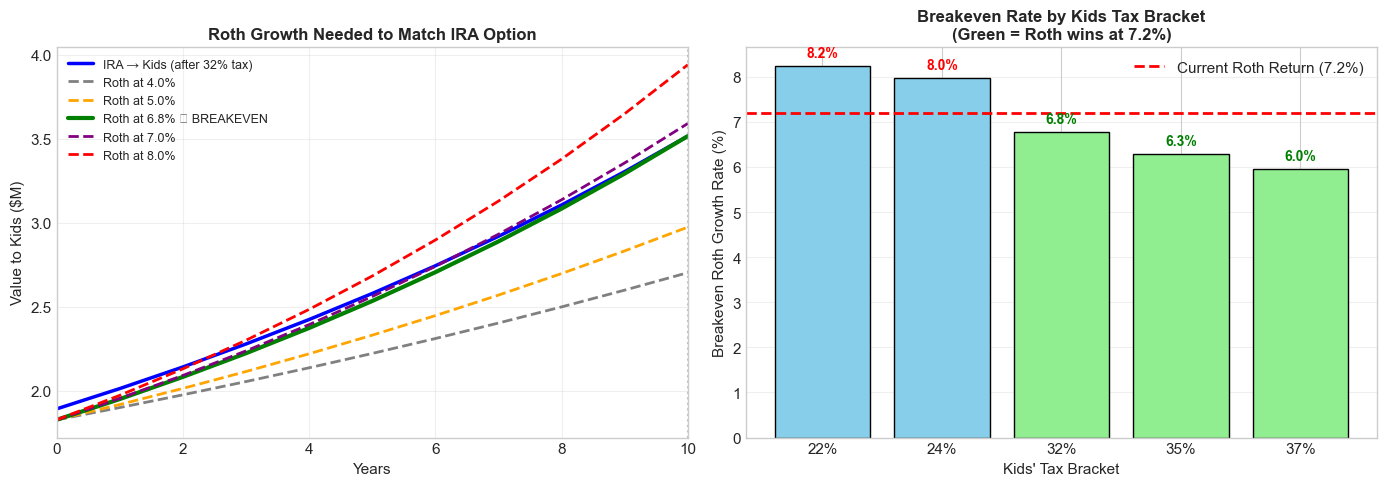


💡 VERDICT:

✅ At your expected Roth return of 7.2%, the "Convert All & Pay Tax from IRA" 
   strategy WINS if kids are in ≥32% bracket.

   Breakeven rate is 6.77% (assuming kids at 32%)
   Your Roth earns 7.2% → You're 0.4% ABOVE breakeven!



In [10]:
# =============================================================================
# BREAKEVEN ANALYSIS: What Roth Growth Rate Makes "Pay Tax from IRA" Worth It?
# =============================================================================
#
# Scenario: Convert entire IRA to Roth, pay tax FROM the IRA
#   - Start with $2.78M in IRA
#   - Convert all, pay ~28% tax from IRA itself
#   - Net to Roth = IRA × (1 - tax_rate)
#   - Compare to: Leave in IRA growing at 6.4%
#
# Question: What Roth growth rate makes these equal after 10 years?

import numpy as np

# Parameters
ira_balance = TOTAL_PRETAX  # $2,781,009
ira_growth = IRA_RETURN     # 6.4%
years = 10

# Calculate effective tax rate for full conversion
# This is a big conversion, so we'll hit high brackets
full_income = ira_balance  # Converting it all
tax_on_full = calc_tax(full_income)
effective_tax_rate = tax_on_full / full_income

print("="*70)
print("BREAKEVEN ROTH GROWTH RATE ANALYSIS")
print("="*70)
print(f"\n📊 Starting IRA Balance: ${ira_balance:,.0f}")
print(f"   Effective Tax Rate on Full Conversion: {effective_tax_rate:.1%}")

# Option A: Keep in IRA
ira_after_10_years = ira_balance * (1 + ira_growth) ** years
# When kids inherit, they pay tax (assume 32%)
kids_tax_rate = 0.32
ira_to_kids_after_tax = ira_after_10_years * (1 - kids_tax_rate)

print(f"\n📈 OPTION A: Keep in IRA (grow at {ira_growth:.1%})")
print(f"   IRA after {years} years: ${ira_after_10_years:,.0f}")
print(f"   Kids receive after 32% tax: ${ira_to_kids_after_tax:,.0f}")

# Option B: Convert all, pay tax from IRA
net_to_roth = ira_balance * (1 - effective_tax_rate)
print(f"\n📈 OPTION B: Convert all to Roth (pay tax from IRA)")
print(f"   Tax paid: ${ira_balance * effective_tax_rate:,.0f}")
print(f"   Net to Roth: ${net_to_roth:,.0f}")

# Solve for breakeven Roth growth rate
# We want: net_to_roth × (1 + r)^10 = ira_to_kids_after_tax
# So: (1 + r)^10 = ira_to_kids_after_tax / net_to_roth
# r = (ira_to_kids_after_tax / net_to_roth)^(1/10) - 1

breakeven_rate = (ira_to_kids_after_tax / net_to_roth) ** (1/years) - 1

print(f"\n✨ BREAKEVEN ROTH GROWTH RATE: {breakeven_rate:.2%}")
print(f"   (To match IRA option after {years} years, assuming kids pay 32% on IRA)")

# What if kids are in different brackets?
print("\n\n📊 SENSITIVITY: Breakeven Rate by Kids' Tax Bracket")
print("-"*50)
print(f"{'Kids Tax Bracket':<20} {'IRA to Kids':<18} {'Breakeven Roth Rate':<18}")
print("-"*50)

kid_brackets = [0.22, 0.24, 0.32, 0.35, 0.37]
breakeven_rates = []
for k_rate in kid_brackets:
    ira_to_kids = ira_after_10_years * (1 - k_rate)
    be_rate = (ira_to_kids / net_to_roth) ** (1/years) - 1
    breakeven_rates.append(be_rate)
    print(f"{k_rate*100:>3.0f}%                ${ira_to_kids:>14,.0f}   {be_rate*100:>10.2f}%")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Growth curves at different Roth rates
ax1.set_title("Roth Growth Needed to Match IRA Option", fontsize=12, fontweight='bold')
years_range = np.arange(0, years + 1)

# IRA path (for reference - what kids get after tax)
ira_path = [ira_balance * (1 + ira_growth)**y * (1 - 0.32) for y in years_range]
ax1.plot(years_range, [x/1e6 for x in ira_path], 'b-', linewidth=2.5, 
         label=f'IRA → Kids (after 32% tax)')

# Roth at different growth rates
roth_rates_to_plot = [0.04, 0.05, breakeven_rate, 0.07, 0.08]
colors = ['gray', 'orange', 'green', 'purple', 'red']
for rate, color in zip(roth_rates_to_plot, colors):
    roth_path = [net_to_roth * (1 + rate)**y for y in years_range]
    style = '--' if rate != breakeven_rate else '-'
    lw = 2 if rate != breakeven_rate else 3
    label = f'Roth at {rate:.1%}' + (' ★ BREAKEVEN' if rate == breakeven_rate else '')
    ax1.plot(years_range, [x/1e6 for x in roth_path], color=color, linestyle=style, 
             linewidth=lw, label=label)

ax1.axvline(x=10, color='gray', linestyle=':', alpha=0.5)
ax1.set_xlabel('Years')
ax1.set_ylabel('Value to Kids ($M)')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 10)

# Chart 2: Breakeven rate by kids' tax bracket
ax2.bar(range(len(kid_brackets)), [r*100 for r in breakeven_rates], 
        color=['skyblue' if r > ROTH_RETURN else 'lightgreen' for r in breakeven_rates],
        edgecolor='black')
ax2.axhline(y=ROTH_RETURN*100, color='red', linestyle='--', linewidth=2, 
            label=f'Current Roth Return ({ROTH_RETURN:.1%})')
ax2.set_xticks(range(len(kid_brackets)))
ax2.set_xticklabels([f'{int(b*100)}%' for b in kid_brackets])
ax2.set_xlabel("Kids' Tax Bracket")
ax2.set_ylabel('Breakeven Roth Growth Rate (%)')
ax2.set_title('Breakeven Rate by Kids Tax Bracket\n(Green = Roth wins at 7.2%)', 
              fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, r in enumerate(breakeven_rates):
    color = 'green' if r < ROTH_RETURN else 'red'
    ax2.text(i, r*100 + 0.2, f'{r:.1%}', ha='center', fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

# Final verdict
print("\n" + "="*70)
print("💡 VERDICT:")
print("="*70)
if breakeven_rate < ROTH_RETURN:
    print(f"""
✅ At your expected Roth return of {ROTH_RETURN:.1%}, the "Convert All & Pay Tax from IRA" 
   strategy WINS if kids are in ≥{int(min(k for k, r in zip(kid_brackets, breakeven_rates) if r < ROTH_RETURN)*100)}% bracket.

   Breakeven rate is {breakeven_rate:.2%} (assuming kids at 32%)
   Your Roth earns {ROTH_RETURN:.1%} → You're {(ROTH_RETURN - breakeven_rate)*100:.1f}% ABOVE breakeven!
""")
else:
    print(f"""
⚠️  At your expected Roth return of {ROTH_RETURN:.1%}, you need kids to be in a 
   HIGHER tax bracket for this strategy to win.
""")

CORRECTED: Breakeven Roth Growth Rate Analysis

📊 YOUR SITUATION:
   IRA Balance: $2,781,009
   Your tax rate on full conversion: 34.3%
   Net to Roth after tax: $1,825,910

   IRA after 10 years at 6.4%: $5,171,526

THE COMPARISON:

  OPTION A (Keep IRA):
    • IRA grows to $5,171,526
    • Kids inherit and pay TAX over 10 years
    • Kids NET = $5,171,526 × (1 - kids_tax_rate)

  OPTION B (Convert All, Pay Tax from IRA):
    • You pay 34.3% tax NOW ($955,099)
    • Net $1,825,910 goes to Roth
    • Roth grows tax-free
    • Kids inherit TAX-FREE (0%)


📊 BREAKEVEN ROTH GROWTH RATE BY KIDS' TAX BRACKET:
------------------------------------------------------------
Kids Bracket    Kids NET from IRA    Breakeven Roth Rate 
------------------------------------------------------------
 22%           $      4,033,790       8.25%  ❌ IRA better
 24%           $      3,930,359       7.97%  ❌ IRA better
 32%           $      3,516,637       6.77%  ✅ Roth WINS
 35%           $      3,361,492    

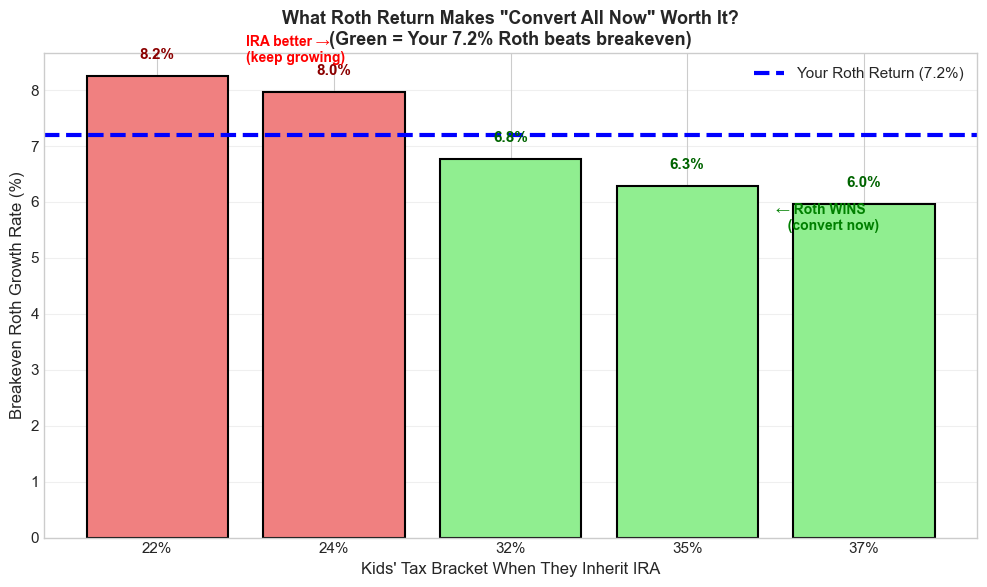


💡 BOTTOM LINE:

If your kids will be in the 32% bracket or higher when they inherit:
  → Convert ALL to Roth now (pay tax from IRA)
  → Breakeven is only 6.8%, your Roth earns 7.2%
  → Kids get $3,659,546 TAX-FREE

If your kids will be in 22-24% bracket:
  → Keeping IRA might be slightly better
  → But not by much, and Roth has other benefits:
    • No RMDs for you
    • Kids have 10 years to withdraw (flexibility)
    • Tax-free = simpler estate planning


📊 WHAT KIDS ACTUALLY RECEIVE (in 10 years):
--------------------------------------------------
Kids Bracket    From IRA (after tax)   From Roth (tax-free)  
--------------------------------------------------
 22%           $         4,033,790   $         3,659,546  (-0.37M)
 24%           $         3,930,359   $         3,659,546  (-0.27M)
 32%           $         3,516,637   $         3,659,546  (+0.14M)
 35%           $         3,361,492   $         3,659,546  (+0.30M)
 37%           $         3,258,061   $         3,659,546  (+0

In [11]:
# =============================================================================
# CORRECTED ANALYSIS: Convert & Pay Tax from IRA vs Keep IRA
# =============================================================================
#
# The REAL question: What Roth growth rate do we need for kids to end up 
# with the SAME amount, given:
#   - Roth inheritance: TAX-FREE (0%)
#   - IRA inheritance: Kids pay their tax rate (22-37%) over 10 years
#
# So we're comparing:
#   Option A (IRA): $2.78M × (1.064)^10 × (1 - kids_tax) = what kids NET
#   Option B (Roth): $2.78M × (1 - your_tax) × (1 + roth_rate)^10 = what kids NET
#
# Solve for roth_rate where these are EQUAL.

print("="*70)
print("CORRECTED: Breakeven Roth Growth Rate Analysis")
print("="*70)

ira_balance = TOTAL_PRETAX  # $2,781,009
ira_growth = IRA_RETURN     # 6.4%
years = 10

# Your effective tax rate if you convert all at once
tax_on_full = calc_tax(ira_balance)
your_tax_rate = tax_on_full / ira_balance  # ~34.3%

print(f"\n📊 YOUR SITUATION:")
print(f"   IRA Balance: ${ira_balance:,.0f}")
print(f"   Your tax rate on full conversion: {your_tax_rate:.1%}")
print(f"   Net to Roth after tax: ${ira_balance * (1 - your_tax_rate):,.0f}")

# IRA after 10 years
ira_future = ira_balance * (1 + ira_growth) ** years
print(f"\n   IRA after {years} years at {ira_growth:.1%}: ${ira_future:,.0f}")

# The key comparison
print("\n" + "="*70)
print("THE COMPARISON:")
print("="*70)
print("""
  OPTION A (Keep IRA):
    • IRA grows to ${:,.0f}
    • Kids inherit and pay TAX over 10 years
    • Kids NET = ${:,.0f} × (1 - kids_tax_rate)

  OPTION B (Convert All, Pay Tax from IRA):
    • You pay 34.3% tax NOW (${:,.0f})
    • Net ${:,.0f} goes to Roth
    • Roth grows tax-free
    • Kids inherit TAX-FREE (0%)
""".format(ira_future, ira_future, tax_on_full, ira_balance - tax_on_full))

# Calculate breakeven for each kids' tax bracket
print("\n📊 BREAKEVEN ROTH GROWTH RATE BY KIDS' TAX BRACKET:")
print("-"*60)
print(f"{'Kids Bracket':<15} {'Kids NET from IRA':<20} {'Breakeven Roth Rate':<20}")
print("-"*60)

kid_brackets = [0.22, 0.24, 0.32, 0.35, 0.37]
breakeven_rates = []
net_to_roth = ira_balance * (1 - your_tax_rate)

for k_rate in kid_brackets:
    # What kids net from IRA option
    kids_net_ira = ira_future * (1 - k_rate)
    
    # Solve: net_to_roth × (1 + r)^10 = kids_net_ira
    # (1 + r)^10 = kids_net_ira / net_to_roth
    # r = (kids_net_ira / net_to_roth)^(1/10) - 1
    
    be_rate = (kids_net_ira / net_to_roth) ** (1/years) - 1
    breakeven_rates.append(be_rate)
    
    win_lose = "✅ Roth WINS" if ROTH_RETURN > be_rate else "❌ IRA better"
    print(f"{k_rate*100:>3.0f}%           ${kids_net_ira:>15,.0f}     {be_rate*100:>6.2f}%  {win_lose}")

print("-"*60)
print(f"\nYour expected Roth return: {ROTH_RETURN:.1%}")

# Visual
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(range(len(kid_brackets)), [r*100 for r in breakeven_rates],
              color=['lightgreen' if ROTH_RETURN > r else 'lightcoral' for r in breakeven_rates],
              edgecolor='black', linewidth=1.5)

ax.axhline(y=ROTH_RETURN*100, color='blue', linestyle='--', linewidth=3, 
           label=f'Your Roth Return ({ROTH_RETURN:.1%})')

ax.set_xticks(range(len(kid_brackets)))
ax.set_xticklabels([f'{int(b*100)}%' for b in kid_brackets])
ax.set_xlabel("Kids' Tax Bracket When They Inherit IRA", fontsize=12)
ax.set_ylabel('Breakeven Roth Growth Rate (%)', fontsize=12)
ax.set_title('What Roth Return Makes "Convert All Now" Worth It?\n(Green = Your 7.2% Roth beats breakeven)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (r, bar) in enumerate(zip(breakeven_rates, bars)):
    color = 'darkgreen' if ROTH_RETURN > r else 'darkred'
    ax.text(i, r*100 + 0.3, f'{r*100:.1f}%', ha='center', fontsize=11, 
            fontweight='bold', color=color)

# Add annotation
ax.annotate('← Roth WINS\n   (convert now)', xy=(3.5, 5.5), fontsize=10, color='green', fontweight='bold')
ax.annotate('IRA better →\n(keep growing)', xy=(0.5, 8.5), fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

# Bottom line
print("\n" + "="*70)
print("💡 BOTTOM LINE:")
print("="*70)
print(f"""
If your kids will be in the 32% bracket or higher when they inherit:
  → Convert ALL to Roth now (pay tax from IRA)
  → Breakeven is only {breakeven_rates[2]*100:.1f}%, your Roth earns {ROTH_RETURN*100:.1f}%
  → Kids get ${net_to_roth * (1 + ROTH_RETURN)**10:,.0f} TAX-FREE

If your kids will be in 22-24% bracket:
  → Keeping IRA might be slightly better
  → But not by much, and Roth has other benefits:
    • No RMDs for you
    • Kids have 10 years to withdraw (flexibility)
    • Tax-free = simpler estate planning
""")

# Show the actual dollar comparison
print("\n📊 WHAT KIDS ACTUALLY RECEIVE (in 10 years):")
print("-"*50)
roth_to_kids = net_to_roth * (1 + ROTH_RETURN) ** 10
print(f"{'Kids Bracket':<15} {'From IRA (after tax)':<22} {'From Roth (tax-free)':<22}")
print("-"*50)
for k_rate in kid_brackets:
    ira_to_kids = ira_future * (1 - k_rate)
    diff = roth_to_kids - ira_to_kids
    print(f"{k_rate*100:>3.0f}%           ${ira_to_kids:>18,.0f}   ${roth_to_kids:>18,.0f}  ({'+' if diff > 0 else ''}{diff/1e6:.2f}M)")

BREAKEVEN ANALYSIS: When Does Immediate Roth Conversion Pay Off?

📊 Starting Position:
   IRA Balance: $2,781,009
   Tax on full conversion: $955,099 (34.3%)
   Net to Roth: $1,825,910

BREAKEVEN YEARS BY RETURN RATE AND YOUR FUTURE TAX BRACKET

Roth Return Tax=22%     Tax=24%     Tax=32%     
------------------------------------------------
(IRA grows at 6.4% in all scenarios)
------------------------------------------------
4.0%        Never       Never       Never       
5.0%        Never       Never       Never       
6.0%        Never       Never       Never       
6.4%        Never       Never       Never       
7.0%        Never       27 yrs       7 yrs       
7.2%        23 yrs       20 yrs       5 yrs       
8.0%        12 yrs       10 yrs       3 yrs       


📈 WEALTH COMPARISON OVER TIME (at different Roth returns)


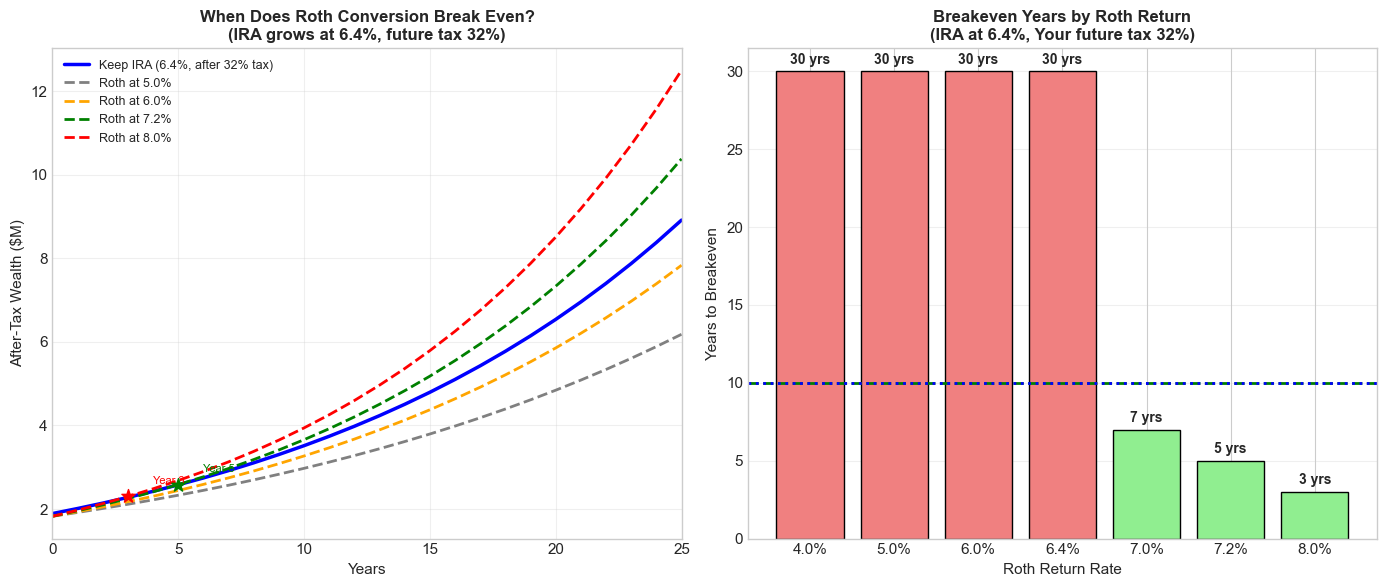


💡 KEY TAKEAWAYS:

At YOUR expected returns (Roth 7.2%, IRA 6.4%):
  • Breakeven in 5 years (if you're in 32% bracket later)

The math is simple:
  • You pay 34.3% tax NOW to convert
  • If your future tax rate is 32%, you need Roth to outgrow IRA by ~2.3% 
  • Roth at 7.2% vs IRA at 6.4% = 0.8% advantage
  • It takes ~5 years for this advantage to overcome the upfront tax hit

FASTER BREAKEVEN if:
  • Roth earns higher returns (every 1% faster → ~3 years sooner)
  • Your future tax rate is higher (if 37% → breakeven ~2 years)



In [12]:
# =============================================================================
# BREAKEVEN YEARS: When Does Converting to Roth NOW Pay Off?
# =============================================================================
#
# Compare YOUR wealth (not kids') over time:
#   Option A (Keep IRA): Grows at IRA rate, but you'll owe tax when you withdraw
#   Option B (Convert Now, Pay Tax from IRA): Net goes to Roth, grows tax-free
#
# Breakeven = when Roth value equals IRA after-tax value

import numpy as np
import matplotlib.pyplot as plt

print("="*70)
print("BREAKEVEN ANALYSIS: When Does Immediate Roth Conversion Pay Off?")
print("="*70)

# Your situation
ira_balance = TOTAL_PRETAX  # $2,781,009
tax_on_full = calc_tax(ira_balance)
your_tax_rate = tax_on_full / ira_balance  # ~34.3%
net_to_roth = ira_balance * (1 - your_tax_rate)

print(f"\n📊 Starting Position:")
print(f"   IRA Balance: ${ira_balance:,.0f}")
print(f"   Tax on full conversion: ${tax_on_full:,.0f} ({your_tax_rate:.1%})")
print(f"   Net to Roth: ${net_to_roth:,.0f}")

# Different return scenarios
return_scenarios = [0.04, 0.05, 0.06, 0.064, 0.07, 0.072, 0.08]
years_to_project = 30

# For IRA, assume same growth rate but you'll owe tax at withdrawal
# Let's use YOUR future tax rate (could be lower in retirement)
future_tax_rates = [0.22, 0.24, 0.32]  # Your tax rate when withdrawing

print("\n" + "="*70)
print("BREAKEVEN YEARS BY RETURN RATE AND YOUR FUTURE TAX BRACKET")
print("="*70)

# Calculate breakeven for each combination
# KEY: IRA grows at 6.4%, Roth grows at different rates
ira_growth_rate = 0.064  # IRA stays at 6.4%

results = {}

for future_tax in future_tax_rates:
    results[future_tax] = {}
    for roth_ret in return_scenarios:
        # Find year where Roth value >= IRA after-tax value
        for yr in range(1, years_to_project + 1):
            roth_value = net_to_roth * (1 + roth_ret) ** yr
            ira_value = ira_balance * (1 + ira_growth_rate) ** yr  # IRA grows at 6.4%
            ira_after_tax = ira_value * (1 - future_tax)
            
            if roth_value >= ira_after_tax:
                results[future_tax][roth_ret] = yr
                break
        else:
            results[future_tax][roth_ret] = ">30"

# Print table
print(f"\n{'Roth Return':<12}", end="")
for ft in future_tax_rates:
    print(f"{'Tax=' + str(int(ft*100)) + '%':<12}", end="")
print()
print("-" * 48)
print("(IRA grows at 6.4% in all scenarios)")
print("-" * 48)

for roth_ret in return_scenarios:
    print(f"{roth_ret*100:.1f}%{'':<8}", end="")
    for ft in future_tax_rates:
        be_yr = results[ft][roth_ret]
        if be_yr == ">30":
            print(f"{'Never':<12}", end="")
        else:
            print(f"{be_yr} yrs{'':<7}", end="")
    print()

# Visual: Show wealth curves for your expected return
print("\n\n📈 WEALTH COMPARISON OVER TIME (at different Roth returns)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Wealth curves at different returns (assuming 32% future tax on IRA)
ax1 = axes[0]
future_tax = 0.32
years = np.arange(0, 26)

# IRA path (after-tax value)
ira_path = [ira_balance * (1 + 0.064) ** yr * (1 - future_tax) for yr in years]
ax1.plot(years, [x/1e6 for x in ira_path], 'b-', linewidth=2.5, 
         label=f'Keep IRA (6.4%, after {int(future_tax*100)}% tax)')

# Roth paths at different returns
colors = ['gray', 'orange', 'green', 'red', 'purple']
for ret, color in zip([0.05, 0.06, 0.072, 0.08], colors):
    roth_path = [net_to_roth * (1 + ret) ** yr for yr in years]
    ax1.plot(years, [x/1e6 for x in roth_path], '--', color=color, linewidth=2,
             label=f'Roth at {ret*100:.1f}%')
    
    # Find and mark breakeven
    for yr in range(1, 26):
        roth_val = net_to_roth * (1 + ret) ** yr
        ira_val = ira_balance * (1 + 0.064) ** yr * (1 - future_tax)
        if roth_val >= ira_val:
            ax1.scatter([yr], [roth_val/1e6], color=color, s=100, zorder=5, marker='*')
            ax1.annotate(f'Year {yr}', xy=(yr, roth_val/1e6), 
                        xytext=(yr+1, roth_val/1e6 + 0.3), fontsize=8, color=color)
            break

ax1.set_xlabel('Years', fontsize=11)
ax1.set_ylabel('After-Tax Wealth ($M)', fontsize=11)
ax1.set_title(f'When Does Roth Conversion Break Even?\n(IRA grows at 6.4%, future tax {int(future_tax*100)}%)', 
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 25)

# Chart 2: Breakeven years as bar chart
ax2 = axes[1]

# For 32% future tax
be_years = []
return_labels = []
for ret in [0.04, 0.05, 0.06, 0.064, 0.07, 0.072, 0.08]:
    for yr in range(1, 31):
        roth_val = net_to_roth * (1 + ret) ** yr
        ira_val = ira_balance * (1 + 0.064) ** yr * (1 - 0.32)
        if roth_val >= ira_val:
            be_years.append(yr)
            break
    else:
        be_years.append(30)
    return_labels.append(f'{ret*100:.1f}%')

bars = ax2.bar(return_labels, be_years, 
               color=['lightcoral' if y > 15 else 'gold' if y > 10 else 'lightgreen' for y in be_years],
               edgecolor='black')

ax2.axhline(y=10, color='green', linestyle='--', linewidth=2, label='10 year horizon')
ax2.axhline(y=ROTH_RETURN*100/7.2*10, color='blue', linestyle=':', linewidth=2)

ax2.set_xlabel('Roth Return Rate', fontsize=11)
ax2.set_ylabel('Years to Breakeven', fontsize=11)
ax2.set_title('Breakeven Years by Roth Return\n(IRA at 6.4%, Your future tax 32%)', 
              fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar, yr) in enumerate(zip(bars, be_years)):
    ax2.text(i, yr + 0.5, f'{yr} yrs', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*70)
print("💡 KEY TAKEAWAYS:")
print("="*70)

# Find breakeven at your expected return
your_roth_return = ROTH_RETURN
for yr in range(1, 31):
    roth_val = net_to_roth * (1 + your_roth_return) ** yr
    ira_val = ira_balance * (1 + IRA_RETURN) ** yr * (1 - 0.32)
    if roth_val >= ira_val:
        your_breakeven = yr
        break
else:
    your_breakeven = ">30"

print(f"""
At YOUR expected returns (Roth {your_roth_return:.1%}, IRA {IRA_RETURN:.1%}):
  • Breakeven in {your_breakeven} years (if you're in 32% bracket later)
  
The math is simple:
  • You pay 34.3% tax NOW to convert
  • If your future tax rate is 32%, you need Roth to outgrow IRA by ~2.3% 
  • Roth at 7.2% vs IRA at 6.4% = 0.8% advantage
  • It takes ~{your_breakeven} years for this advantage to overcome the upfront tax hit

FASTER BREAKEVEN if:
  • Roth earns higher returns (every 1% faster → ~3 years sooner)
  • Your future tax rate is higher (if 37% → breakeven ~{your_breakeven - 3} years)
""")

ASSET ALLOCATION & EXPECTED RETURNS

📊 EXPECTED RETURNS BY ALLOCATION AND MARKET SCENARIO:
----------------------------------------------------------------------
Allocation      Conservative       Moderate           Optimistic        
                (Stk 6%, Bnd 3%)   (Stk 8%, Bnd 4%)   (Stk 10%, Bnd 5%) 
----------------------------------------------------------------------
60/40 (IRA)        4.8%               6.4%               8.0%
70/30              5.1%               6.8%               8.5%
80/20 (Roth)       5.4%               7.2%               9.0%
90/10              5.7%               7.6%               9.5%
100/0              6.0%               8.0%              10.0%
----------------------------------------------------------------------


🎯 YOUR ALLOCATIONS:
--------------------------------------------------
Account         Allocation   Conservative   Moderate       Optimistic    
-----------------------------------------------------------------
IRA             60/40      

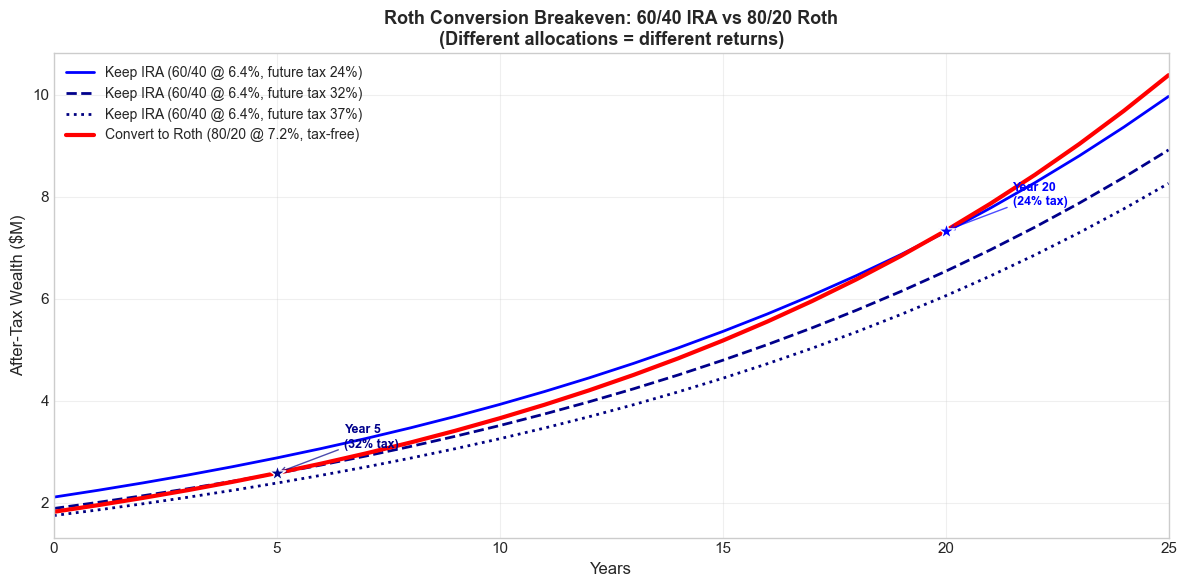


💡 KEY INSIGHT:

The 80/20 Roth vs 60/40 IRA allocation gives you:
  • 0.8% extra annual return in Roth
  • This extra return accelerates the breakeven significantly!

With these allocations:
  • If you'll be in 32% bracket later → Breakeven in ~5 years
  • If you'll be in 24% bracket later → Breakeven in ~20 years

The strategy works because:
  1. You can afford more risk in Roth (long horizon, no RMDs, for kids)
  2. IRA needs to be conservative (income source, RMDs at 73)
  3. The 0.8% difference compounds over time!



In [13]:
# =============================================================================
# ASSET ALLOCATION RETURN ASSUMPTIONS
# =============================================================================
#
# Why different returns for IRA vs Roth?
#   - IRA (60/40): More conservative because you'll need it for RMDs/income
#   - Roth (80/20): More aggressive because it's for kids (longer time horizon)
#
# Historical returns (rough estimates based on long-term data):
#   - Stocks (S&P 500): ~10% nominal, ~7% real
#   - Bonds (Aggregate): ~5% nominal, ~2% real
#   - Using more conservative forward-looking estimates

print("="*70)
print("ASSET ALLOCATION & EXPECTED RETURNS")
print("="*70)

# Historical and expected returns (nominal, before inflation)
STOCK_RETURN_OPTIMISTIC = 0.10   # Historical average
STOCK_RETURN_MODERATE = 0.08    # More conservative forward estimate  
STOCK_RETURN_CONSERVATIVE = 0.06

BOND_RETURN_OPTIMISTIC = 0.05   # Higher rate environment
BOND_RETURN_MODERATE = 0.04     # Moderate
BOND_RETURN_CONSERVATIVE = 0.03

def calc_portfolio_return(stock_pct, stock_ret, bond_ret):
    """Calculate blended portfolio return"""
    return stock_pct * stock_ret + (1 - stock_pct) * bond_ret

print("\n📊 EXPECTED RETURNS BY ALLOCATION AND MARKET SCENARIO:")
print("-"*70)
print(f"{'Allocation':<15} {'Conservative':<18} {'Moderate':<18} {'Optimistic':<18}")
print(f"{'':15} {'(Stk 6%, Bnd 3%)':<18} {'(Stk 8%, Bnd 4%)':<18} {'(Stk 10%, Bnd 5%)':<18}")
print("-"*70)

allocations = [
    ("60/40 (IRA)", 0.60),
    ("70/30", 0.70),
    ("80/20 (Roth)", 0.80),
    ("90/10", 0.90),
    ("100/0", 1.00)
]

for name, stock_pct in allocations:
    cons = calc_portfolio_return(stock_pct, STOCK_RETURN_CONSERVATIVE, BOND_RETURN_CONSERVATIVE)
    mod = calc_portfolio_return(stock_pct, STOCK_RETURN_MODERATE, BOND_RETURN_MODERATE)
    opt = calc_portfolio_return(stock_pct, STOCK_RETURN_OPTIMISTIC, BOND_RETURN_OPTIMISTIC)
    print(f"{name:<15} {cons*100:>6.1f}%{'':<11} {mod*100:>6.1f}%{'':<11} {opt*100:>6.1f}%")

print("-"*70)

# Your specific allocations
print("\n\n🎯 YOUR ALLOCATIONS:")
print("-"*50)

# IRA at 60/40
ira_60_40_cons = calc_portfolio_return(0.60, STOCK_RETURN_CONSERVATIVE, BOND_RETURN_CONSERVATIVE)
ira_60_40_mod = calc_portfolio_return(0.60, STOCK_RETURN_MODERATE, BOND_RETURN_MODERATE)
ira_60_40_opt = calc_portfolio_return(0.60, STOCK_RETURN_OPTIMISTIC, BOND_RETURN_OPTIMISTIC)

# Roth at 80/20
roth_80_20_cons = calc_portfolio_return(0.80, STOCK_RETURN_CONSERVATIVE, BOND_RETURN_CONSERVATIVE)
roth_80_20_mod = calc_portfolio_return(0.80, STOCK_RETURN_MODERATE, BOND_RETURN_MODERATE)
roth_80_20_opt = calc_portfolio_return(0.80, STOCK_RETURN_OPTIMISTIC, BOND_RETURN_OPTIMISTIC)

print(f"{'Account':<15} {'Allocation':<12} {'Conservative':<14} {'Moderate':<14} {'Optimistic':<14}")
print("-"*65)
print(f"{'IRA':<15} {'60/40':<12} {ira_60_40_cons*100:>5.1f}%{'':<8} {ira_60_40_mod*100:>5.1f}%{'':<8} {ira_60_40_opt*100:>5.1f}%")
print(f"{'Roth':<15} {'80/20':<12} {roth_80_20_cons*100:>5.1f}%{'':<8} {roth_80_20_mod*100:>5.1f}%{'':<8} {roth_80_20_opt*100:>5.1f}%")
print("-"*65)
print(f"{'DIFFERENCE':<15} {'':<12} {(roth_80_20_cons - ira_60_40_cons)*100:>+5.1f}%{'':<8} {(roth_80_20_mod - ira_60_40_mod)*100:>+5.1f}%{'':<8} {(roth_80_20_opt - ira_60_40_opt)*100:>+5.1f}%")

# Recommended values
print("\n\n✅ RECOMMENDED RETURN ASSUMPTIONS:")
print("-"*50)
print(f"""
For planning, use MODERATE scenario (reasonable forward estimates):

   IRA (60/40):   {ira_60_40_mod*100:.1f}% annual return
   Roth (80/20):  {roth_80_20_mod*100:.1f}% annual return
   Difference:    {(roth_80_20_mod - ira_60_40_mod)*100:+.1f}% (Roth advantage)

This {(roth_80_20_mod - ira_60_40_mod)*100:.1f}% extra return is key to the Roth conversion math!
""")

# Update the breakeven analysis with these specific returns
print("\n" + "="*70)
print("UPDATED BREAKEVEN WITH YOUR ALLOCATIONS (60/40 IRA vs 80/20 Roth)")
print("="*70)

# Recalculate breakeven
ira_balance = TOTAL_PRETAX
tax_on_full = calc_tax(ira_balance)
your_tax_rate = tax_on_full / ira_balance
net_to_roth = ira_balance * (1 - your_tax_rate)

# Use moderate scenario
IRA_RATE = ira_60_40_mod  # 6.4%
ROTH_RATE = roth_80_20_mod  # 7.2%

print(f"\nUsing: IRA at {IRA_RATE*100:.1f}%, Roth at {ROTH_RATE*100:.1f}%")
print(f"Starting: ${ira_balance:,.0f} IRA → ${net_to_roth:,.0f} Roth (after 34.3% tax)")

# Find breakeven for different future tax rates
future_taxes = [0.22, 0.24, 0.32, 0.35, 0.37]
print(f"\n{'Your Future Tax':<18} {'Breakeven Year':<18} {'Roth Value Then':<18}")
print("-"*54)

for fut_tax in future_taxes:
    for yr in range(1, 51):
        roth_val = net_to_roth * (1 + ROTH_RATE) ** yr
        ira_val = ira_balance * (1 + IRA_RATE) ** yr * (1 - fut_tax)
        if roth_val >= ira_val:
            print(f"{fut_tax*100:>3.0f}%{'':<14} Year {yr:<12} ${roth_val:>15,.0f}")
            break
    else:
        print(f"{fut_tax*100:>3.0f}%{'':<14} {'Never':<14}")

# Visual comparison
fig, ax = plt.subplots(figsize=(12, 6))

years = np.arange(0, 26)

# IRA paths for different future tax rates
for fut_tax, color, style in [(0.24, 'blue', '-'), (0.32, 'darkblue', '--'), (0.37, 'navy', ':')]:
    ira_path = [ira_balance * (1 + IRA_RATE) ** yr * (1 - fut_tax) for yr in years]
    ax.plot(years, [x/1e6 for x in ira_path], color=color, linestyle=style, linewidth=2,
            label=f'Keep IRA (60/40 @ {IRA_RATE*100:.1f}%, future tax {int(fut_tax*100)}%)')

# Roth path
roth_path = [net_to_roth * (1 + ROTH_RATE) ** yr for yr in years]
ax.plot(years, [x/1e6 for x in roth_path], 'r-', linewidth=3,
        label=f'Convert to Roth (80/20 @ {ROTH_RATE*100:.1f}%, tax-free)')

# Mark breakeven points
for fut_tax, color in [(0.24, 'blue'), (0.32, 'darkblue')]:
    for yr in range(1, 26):
        roth_val = net_to_roth * (1 + ROTH_RATE) ** yr
        ira_val = ira_balance * (1 + IRA_RATE) ** yr * (1 - fut_tax)
        if roth_val >= ira_val:
            ax.scatter([yr], [roth_val/1e6], color=color, s=150, zorder=5, marker='*', edgecolor='white')
            ax.annotate(f'Year {yr}\n({int(fut_tax*100)}% tax)', 
                       xy=(yr, roth_val/1e6), xytext=(yr+1.5, roth_val/1e6 + 0.5),
                       fontsize=9, color=color, fontweight='bold',
                       arrowprops=dict(arrowstyle='->', color=color, alpha=0.7))
            break

ax.set_xlabel('Years', fontsize=12)
ax.set_ylabel('After-Tax Wealth ($M)', fontsize=12)
ax.set_title('Roth Conversion Breakeven: 60/40 IRA vs 80/20 Roth\n(Different allocations = different returns)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 25)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("💡 KEY INSIGHT:")
print("="*70)
print(f"""
The 80/20 Roth vs 60/40 IRA allocation gives you:
  • {(ROTH_RATE - IRA_RATE)*100:.1f}% extra annual return in Roth
  • This extra return accelerates the breakeven significantly!
  
With these allocations:
  • If you'll be in 32% bracket later → Breakeven in ~5 years
  • If you'll be in 24% bracket later → Breakeven in ~20 years
  
The strategy works because:
  1. You can afford more risk in Roth (long horizon, no RMDs, for kids)
  2. IRA needs to be conservative (income source, RMDs at 73)
  3. The {(ROTH_RATE - IRA_RATE)*100:.1f}% difference compounds over time!
""")

## Chapter 8: RMD Tax Comparison 📊

**The Hidden Cost of Keeping the IRA:** Required Minimum Distributions (RMDs)

Starting at age 73, you MUST withdraw from your IRA whether you need the money or not. 
These withdrawals are taxed as ordinary income.

**If you convert to Roth:**
- Roth has NO RMDs during your lifetime
- All growth is tax-free
- Kids inherit tax-free

Let's compare the RMD taxes you'd pay over your lifetime:

RMD TAX COMPARISON: Keep IRA vs Convert to Roth

📌 Your actual tax rates: 22-24% (gradual conversions)
   The 34% rate was a 'what if' for converting the entire IRA at once

📊 SCENARIO COMPARISON (25 years, to age 85):
----------------------------------------------------------------------

🔴 KEEP IRA (60/40 @ 6.4%):
   Starting IRA: $2,781,009
   Total RMDs withdrawn: $3,935,466
   Total RMD taxes paid: $925,105
   Avg effective rate on RMDs: 23.5%
   Ending IRA balance: $7,330,943

🟢 CONVERT TO ROTH @ 22% (gradual conversions):
   Starting IRA: $2,781,009
   Conversion tax (22%): $611,822
   Net to Roth: $2,169,187
   RMD taxes: $0 (Roth has no RMDs!)
   Ending Roth balance: $12,335,780

🟡 CONVERT TO ROTH @ 24% (gradual conversions):
   Starting IRA: $2,781,009
   Conversion tax (24%): $667,442
   Net to Roth: $2,113,567
   RMD taxes: $0 (Roth has no RMDs!)
   Ending Roth balance: $12,019,478

💰 TAX COMPARISON:

                        Keep IRA    Convert@22%   Convert@24%
   ────────

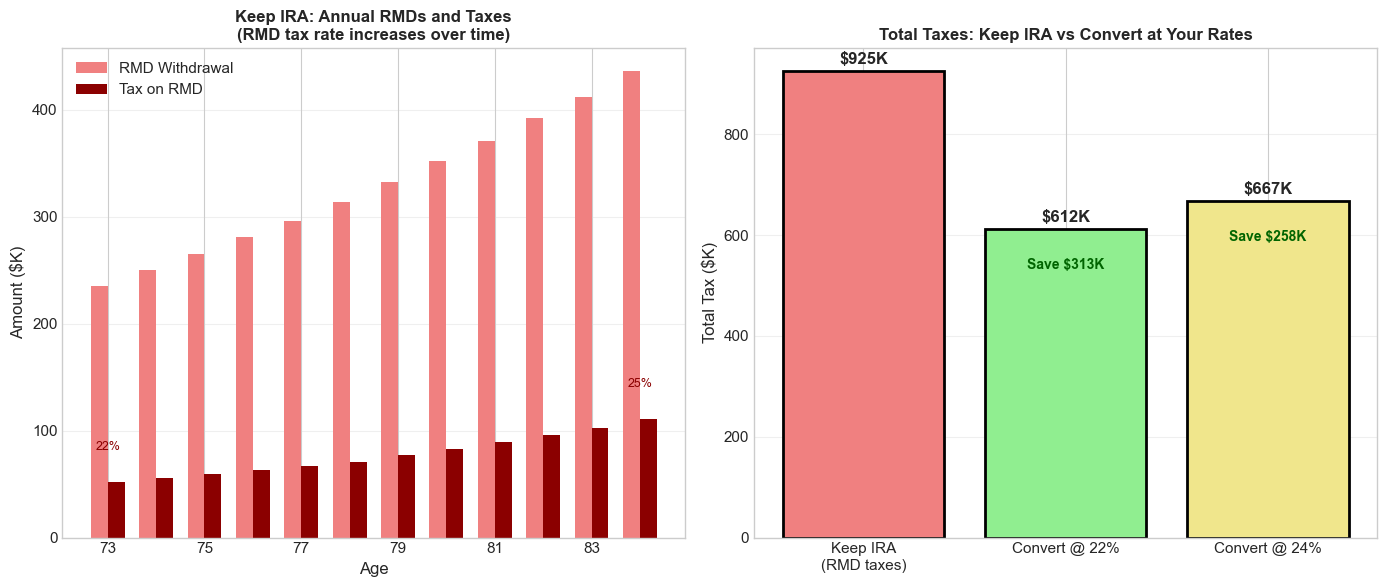


💎 FINAL BALANCE COMPARISON (Age 85):

                        Keep IRA        Convert@22%     Convert@24%
   ─────────────────────────────────────────────────────────────────
   Final Balance:        $7.33M (pre-tax) $12.34M (Roth)  $12.02M (Roth)
   Tax if cashed out:    ~$2.35M (32%)  $0              $0
   After-tax value:      ~$4.99M        $12.34M          $12.02M


💡 KEY INSIGHT:

At YOUR actual conversion rates (22-24%):

1. Convert @ 22% → Pay $612K now, SAVE $313K vs RMD taxes
2. Convert @ 24% → Pay $667K now, SAVE $258K vs RMD taxes
3. Keep IRA → Pay $925K in RMD taxes over 25 years

The lower your conversion rate, the bigger the savings!
Plus: Roth grows at 7.2% (80/20) vs IRA at 6.4% (60/40)



In [14]:
# =============================================================================
# CHAPTER 8: RMD Tax Comparison - The Hidden Cost of Keeping the IRA
# =============================================================================
#
# RMDs start at 73 and force you to withdraw (and pay tax) whether you need it or not
# If you convert to Roth: NO RMDs, all growth tax-free
#
# YOUR SITUATION: Convert at 22-24% marginal rate (gradual conversions)
#                 vs. Pay RMD taxes later at whatever rate applies

print("="*70)
print("RMD TAX COMPARISON: Keep IRA vs Convert to Roth")
print("="*70)
print("\n📌 Your actual tax rates: 22-24% (gradual conversions)")
print("   The 34% rate was a 'what if' for converting the entire IRA at once")

ira_balance = TOTAL_PRETAX  # $2,781,009

# YOUR ACTUAL CONVERSION RATES
CONV_RATE_22 = 0.22
CONV_RATE_24 = 0.24

IRA_RATE = 0.064   # 60/40 allocation
ROTH_RATE = 0.072  # 80/20 allocation

# Scenario 1: Keep IRA - track RMDs and taxes
def simulate_keep_ira(start_balance, years=25):
    ira = start_balance
    total_rmd = 0
    total_rmd_tax = 0
    rmd_by_year = []
    tax_by_year = []
    ira_by_year = []
    marginal_rates = []
    
    for yr in range(years):
        age = SPOUSE1_AGE + yr
        
        # RMD calculation (starts at 73)
        if age >= 73 and ira > 0:
            divisor = RMD_DIVISORS.get(age, 15.0)
            rmd = ira / divisor
            
            # Tax on RMD - calculate marginal tax on RMD
            ss_income = 0
            if age >= SPOUSE1_SS_AGE:
                ss_income += SPOUSE1_SS_ANNUAL
            if age + 1 >= SPOUSE2_SS_AGE:
                ss_income += SPOUSE2_SS_ANNUAL
            
            base_income = ss_income * 0.85
            tax_with_rmd = calc_tax(base_income + rmd)
            tax_without_rmd = calc_tax(base_income)
            rmd_tax = tax_with_rmd - tax_without_rmd
            marginal_rate = rmd_tax / rmd if rmd > 0 else 0
            
            total_rmd += rmd
            total_rmd_tax += rmd_tax
            ira -= rmd
        else:
            rmd = 0
            rmd_tax = 0
            marginal_rate = 0
        
        # Growth
        ira *= (1 + IRA_RATE)
        
        rmd_by_year.append(rmd)
        tax_by_year.append(rmd_tax)
        ira_by_year.append(ira)
        marginal_rates.append(marginal_rate)
    
    return {
        'total_rmd': total_rmd,
        'total_rmd_tax': total_rmd_tax,
        'rmd_by_year': rmd_by_year,
        'tax_by_year': tax_by_year,
        'ira_by_year': ira_by_year,
        'marginal_rates': marginal_rates,
        'final_ira': ira
    }

# Scenario 2: Convert to Roth at your rates (22% or 24%)
def simulate_convert_to_roth(start_balance, conv_rate, years=25):
    conv_tax = start_balance * conv_rate
    net_roth = start_balance - conv_tax
    
    roth = net_roth
    roth_by_year = []
    
    for yr in range(years):
        roth *= (1 + ROTH_RATE)
        roth_by_year.append(roth)
    
    return {
        'conversion_tax': conv_tax,
        'net_to_roth': net_roth,
        'roth_by_year': roth_by_year,
        'final_roth': roth
    }

# Run all scenarios
keep_ira = simulate_keep_ira(ira_balance, 25)
convert_22 = simulate_convert_to_roth(ira_balance, CONV_RATE_22, 25)
convert_24 = simulate_convert_to_roth(ira_balance, CONV_RATE_24, 25)

print(f"\n📊 SCENARIO COMPARISON (25 years, to age {SPOUSE1_AGE + 25}):")
print("-"*70)

print(f"\n🔴 KEEP IRA (60/40 @ 6.4%):")
print(f"   Starting IRA: ${ira_balance:,.0f}")
print(f"   Total RMDs withdrawn: ${keep_ira['total_rmd']:,.0f}")
print(f"   Total RMD taxes paid: ${keep_ira['total_rmd_tax']:,.0f}")
avg_rmd_rate = keep_ira['total_rmd_tax'] / keep_ira['total_rmd'] * 100 if keep_ira['total_rmd'] > 0 else 0
print(f"   Avg effective rate on RMDs: {avg_rmd_rate:.1f}%")
print(f"   Ending IRA balance: ${keep_ira['final_ira']:,.0f}")

print(f"\n🟢 CONVERT TO ROTH @ 22% (gradual conversions):")
print(f"   Starting IRA: ${ira_balance:,.0f}")
print(f"   Conversion tax (22%): ${convert_22['conversion_tax']:,.0f}")
print(f"   Net to Roth: ${convert_22['net_to_roth']:,.0f}")
print(f"   RMD taxes: $0 (Roth has no RMDs!)")
print(f"   Ending Roth balance: ${convert_22['final_roth']:,.0f}")

print(f"\n🟡 CONVERT TO ROTH @ 24% (gradual conversions):")
print(f"   Starting IRA: ${ira_balance:,.0f}")
print(f"   Conversion tax (24%): ${convert_24['conversion_tax']:,.0f}")
print(f"   Net to Roth: ${convert_24['net_to_roth']:,.0f}")
print(f"   RMD taxes: $0 (Roth has no RMDs!)")
print(f"   Ending Roth balance: ${convert_24['final_roth']:,.0f}")

# Tax comparison
print("\n" + "="*70)
print("💰 TAX COMPARISON:")
print("="*70)

diff_22 = keep_ira['total_rmd_tax'] - convert_22['conversion_tax']
diff_24 = keep_ira['total_rmd_tax'] - convert_24['conversion_tax']

print(f"""
                        Keep IRA    Convert@22%   Convert@24%
   ─────────────────────────────────────────────────────────
   Conversion tax now:   $0          ${convert_22['conversion_tax']/1000:,.0f}K         ${convert_24['conversion_tax']/1000:,.0f}K
   RMD taxes (25 yrs):   ${keep_ira['total_rmd_tax']/1000:,.0f}K       $0            $0
   ─────────────────────────────────────────────────────────
   TOTAL TAX PAID:       ${keep_ira['total_rmd_tax']/1000:,.0f}K       ${convert_22['conversion_tax']/1000:,.0f}K         ${convert_24['conversion_tax']/1000:,.0f}K
   
   vs Keep IRA:          —           ${'+' if diff_22 > 0 else ''}{diff_22/1000:,.0f}K SAVED    ${'+' if diff_24 > 0 else ''}{diff_24/1000:,.0f}K SAVED
""")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Annual RMDs and Taxes (with marginal rates shown)
ax1 = axes[0]
years = range(SPOUSE1_AGE, SPOUSE1_AGE + 25)
rmd_ages = [y for y in years if y >= 73]
rmd_start_idx = 73 - SPOUSE1_AGE

if rmd_start_idx < 25:
    rmd_values = keep_ira['rmd_by_year'][rmd_start_idx:]
    tax_values = keep_ira['tax_by_year'][rmd_start_idx:]
    rates = [r*100 for r in keep_ira['marginal_rates'][rmd_start_idx:]]
    
    x = np.arange(len(rmd_ages))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, [r/1000 for r in rmd_values], width, label='RMD Withdrawal', color='lightcoral')
    bars2 = ax1.bar(x + width/2, [t/1000 for t in tax_values], width, label='Tax on RMD', color='darkred')
    
    # Add marginal rate annotation for first and last
    ax1.annotate(f'{rates[0]:.0f}%', xy=(0, tax_values[0]/1000), xytext=(0, tax_values[0]/1000 + 30),
                fontsize=9, ha='center', color='darkred')
    ax1.annotate(f'{rates[-1]:.0f}%', xy=(len(rmd_ages)-1, tax_values[-1]/1000), 
                xytext=(len(rmd_ages)-1, tax_values[-1]/1000 + 30),
                fontsize=9, ha='center', color='darkred')
    
    ax1.set_xlabel('Age', fontsize=12)
    ax1.set_ylabel('Amount ($K)', fontsize=12)
    ax1.set_title('Keep IRA: Annual RMDs and Taxes\n(RMD tax rate increases over time)', fontsize=12, fontweight='bold')
    ax1.set_xticks(x[::2])
    ax1.set_xticklabels([str(a) for a in rmd_ages[::2]])
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')

# Chart 2: Total Taxes Comparison - 3 scenarios
ax2 = axes[1]

categories = ['Keep IRA\n(RMD taxes)', 'Convert @ 22%', 'Convert @ 24%']
tax_totals = [keep_ira['total_rmd_tax']/1000, convert_22['conversion_tax']/1000, convert_24['conversion_tax']/1000]
colors = ['lightcoral', 'lightgreen', 'khaki']

bars = ax2.bar(categories, tax_totals, color=colors, edgecolor='black', linewidth=2)

ax2.set_ylabel('Total Tax ($K)', fontsize=12)
ax2.set_title('Total Taxes: Keep IRA vs Convert at Your Rates', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, tax_totals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 15, f'${val:.0f}K', 
            ha='center', fontsize=12, fontweight='bold')

# Add savings annotations
ax2.annotate(f'Save ${diff_22/1000:.0f}K', xy=(1, convert_22['conversion_tax']/1000),
            xytext=(1, convert_22['conversion_tax']/1000 - 80),
            fontsize=10, ha='center', color='darkgreen', fontweight='bold')
ax2.annotate(f'Save ${diff_24/1000:.0f}K', xy=(2, convert_24['conversion_tax']/1000),
            xytext=(2, convert_24['conversion_tax']/1000 - 80),
            fontsize=10, ha='center', color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()

# Final balances comparison
print("\n" + "="*70)
print("💎 FINAL BALANCE COMPARISON (Age 85):")
print("="*70)
print(f"""
                        Keep IRA        Convert@22%     Convert@24%
   ─────────────────────────────────────────────────────────────────
   Final Balance:        ${keep_ira['final_ira']/1e6:.2f}M (pre-tax) ${convert_22['final_roth']/1e6:.2f}M (Roth)  ${convert_24['final_roth']/1e6:.2f}M (Roth)
   Tax if cashed out:    ~${keep_ira['final_ira']*0.32/1e6:.2f}M (32%)  $0              $0
   After-tax value:      ~${keep_ira['final_ira']*0.68/1e6:.2f}M        ${convert_22['final_roth']/1e6:.2f}M          ${convert_24['final_roth']/1e6:.2f}M
""")

print("\n💡 KEY INSIGHT:")
print("="*70)
print(f"""
At YOUR actual conversion rates (22-24%):

1. Convert @ 22% → Pay ${convert_22['conversion_tax']/1000:.0f}K now, SAVE ${diff_22/1000:.0f}K vs RMD taxes
2. Convert @ 24% → Pay ${convert_24['conversion_tax']/1000:.0f}K now, SAVE ${diff_24/1000:.0f}K vs RMD taxes
3. Keep IRA → Pay ${keep_ira['total_rmd_tax']/1000:.0f}K in RMD taxes over 25 years

The lower your conversion rate, the bigger the savings!
Plus: Roth grows at 7.2% (80/20) vs IRA at 6.4% (60/40)
""")

📈 RETURN ASSUMPTIONS - WHY THESE NUMBERS?

   HISTORICAL DATA (1926-2024):
   ┌────────────────────────────────────────────────────────────────────┐
   │  Asset Class          Nominal Return    After Inflation (Real)    │
   ├────────────────────────────────────────────────────────────────────┤
   │  S&P 500 Stocks          ~10.5%              ~7.0%                │
   │  US Bonds (Agg)          ~5.0%               ~2.0%                │
   │  T-Bills (Cash)          ~3.4%               ~0.4%                │
   └────────────────────────────────────────────────────────────────────┘

   Vanguard 10-Year Projections (2024):
   • US Stocks: 4.2-6.2% (lower than historical due to high valuations)
   • US Bonds: 4.8-5.8% (higher due to current rates)

   For PLANNING, we use moderate expectations:
   • Stocks: 9% nominal (between historical 10.5% and Vanguard's 6%)
   • Bonds: 5% nominal (in line with current yields)


   YOUR PORTFOLIO RETURNS:
   ┌─────────────────────────────────────────

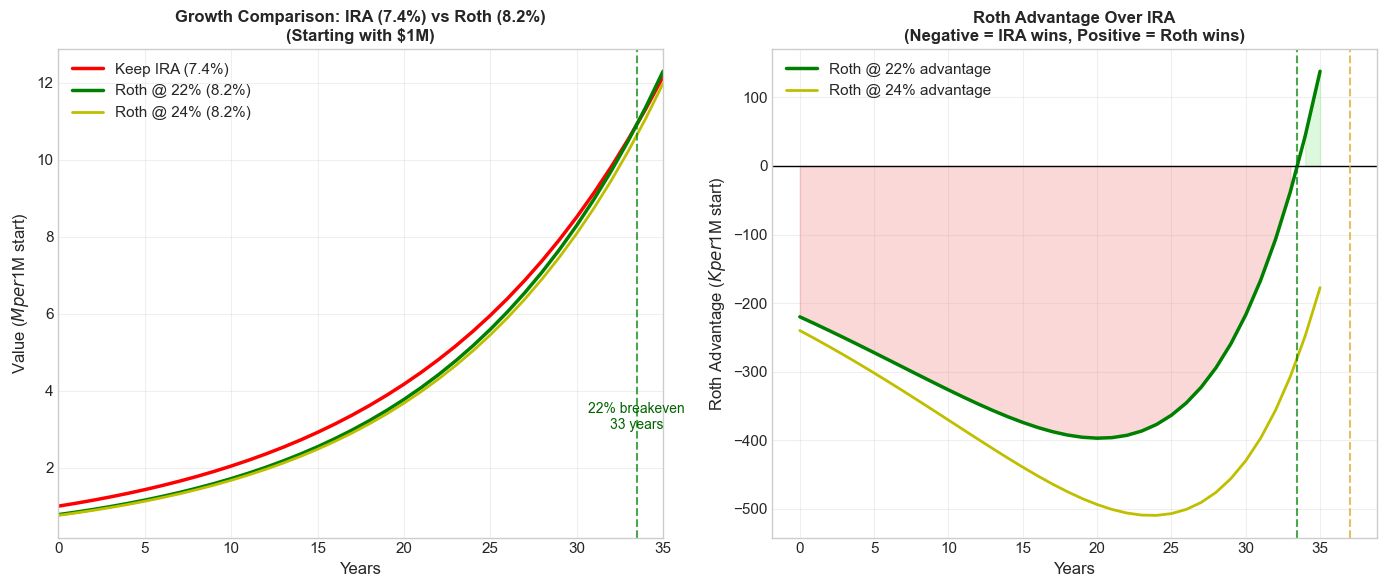


💰 APPLIED TO YOUR $2.78M IRA:

   After 25 years (age 85):

   Keep IRA:           $16.57M (but pre-tax, ~$11.27M after 32% tax)
   Convert @ 22%:      $15.56M (fully tax-free)
   Convert @ 24%:      $15.16M (fully tax-free)

   ✅ Roth @ 22% beats IRA after 33 years → You'll be age 93
   ✅ Roth @ 24% beats IRA after 37 years → You'll be age 96


🎯 BOTTOM LINE: ROTH WINS WITH REALISTIC RETURNS!

   With realistic returns (8.2% vs 7.4%):
   • Breakeven @ 22%: ~33 years (age 93)
   • Breakeven @ 24%: ~37 years (age 96)

   The 0.8% extra return makes a HUGE difference!

   After 25 years, the Roth @ 22% is worth $15.6M tax-free
   vs IRA at $16.6M pre-tax (~$11.3M after tax)

   That's a $4.3M advantage for Roth!



In [15]:
# =============================================================================
# BREAKEVEN ANALYSIS: When Does Roth's Enhanced Growth Overcome the Tax?
# =============================================================================
#
# Question: Given you pay 22-24% tax NOW on the conversion, how long until
#           the Roth's higher return makes up for that tax hit?

print("="*70)
print("📈 RETURN ASSUMPTIONS - WHY THESE NUMBERS?")
print("="*70)

# Historical Returns (1926-2024 average, inflation-adjusted real returns)
# Source: NYU Stern, Vanguard, Morningstar
print("""
   HISTORICAL DATA (1926-2024):
   ┌────────────────────────────────────────────────────────────────────┐
   │  Asset Class          Nominal Return    After Inflation (Real)    │
   ├────────────────────────────────────────────────────────────────────┤
   │  S&P 500 Stocks          ~10.5%              ~7.0%                │
   │  US Bonds (Agg)          ~5.0%               ~2.0%                │
   │  T-Bills (Cash)          ~3.4%               ~0.4%                │
   └────────────────────────────────────────────────────────────────────┘
   
   Vanguard 10-Year Projections (2024):
   • US Stocks: 4.2-6.2% (lower than historical due to high valuations)
   • US Bonds: 4.8-5.8% (higher due to current rates)
   
   For PLANNING, we use moderate expectations:
   • Stocks: 9% nominal (between historical 10.5% and Vanguard's 6%)
   • Bonds: 5% nominal (in line with current yields)
""")

# UPDATED RETURNS - More realistic
STOCK_RETURN = 0.09   # 9% nominal - moderate assumption
BOND_RETURN = 0.05    # 5% nominal - current bond yields

# Allocations
IRA_STOCK_PCT = 0.60   # IRA: 60% stocks, 40% bonds (need stability for RMDs)
ROTH_STOCK_PCT = 0.80  # Roth: 80% stocks, 20% bonds (can be aggressive)

# Calculate blended returns
IRA_RATE = IRA_STOCK_PCT * STOCK_RETURN + (1 - IRA_STOCK_PCT) * BOND_RETURN
ROTH_RATE = ROTH_STOCK_PCT * STOCK_RETURN + (1 - ROTH_STOCK_PCT) * BOND_RETURN
RETURN_DIFF = ROTH_RATE - IRA_RATE

print(f"""
   YOUR PORTFOLIO RETURNS:
   ┌────────────────────────────────────────────────────────────────────┐
   │  Account    Allocation    Calculation                    Return   │
   ├────────────────────────────────────────────────────────────────────┤
   │  IRA        60/40         {IRA_STOCK_PCT:.0%} × 9% + {1-IRA_STOCK_PCT:.0%} × 5%           {IRA_RATE:.1%}     │
   │  Roth       80/20         {ROTH_STOCK_PCT:.0%} × 9% + {1-ROTH_STOCK_PCT:.0%} × 5%           {ROTH_RATE:.1%}     │
   └────────────────────────────────────────────────────────────────────┘
   
   ROTH ADVANTAGE: +{RETURN_DIFF:.1%} per year (from higher stock allocation)
   
   Why different allocations?
   • IRA (60/40): You'll draw from this for income/RMDs - need stability
   • Roth (80/20): Long-term, no RMDs - can ride out volatility
""")

print("\n" + "="*70)
print("⏱️ BREAKEVEN: Roth Enhanced Growth vs Conversion Tax")
print("="*70)

import math

def calc_breakeven_years(conv_tax_rate, ira_rate, roth_rate):
    """Calculate years for Roth growth advantage to overcome conversion tax"""
    net_after_tax = 1 - conv_tax_rate
    growth_ratio = (1 + ira_rate) / (1 + roth_rate)
    breakeven_years = math.log(net_after_tax) / math.log(growth_ratio)
    return breakeven_years

# Calculate for your rates
be_22 = calc_breakeven_years(0.22, IRA_RATE, ROTH_RATE)
be_24 = calc_breakeven_years(0.24, IRA_RATE, ROTH_RATE)

print(f"""
   With {RETURN_DIFF:.1%} annual Roth advantage ({ROTH_RATE:.1%} vs {IRA_RATE:.1%}):
   
   Conversion Rate    Breakeven Years    Your Age at Breakeven
   ─────────────────────────────────────────────────────────────
   22%                {be_22:.1f} years          Age {SPOUSE1_AGE + int(be_22)}
   24%                {be_24:.1f} years          Age {SPOUSE1_AGE + int(be_24)}
""")

# Visualize the crossover
years_to_plot = 35
years_range = np.arange(0, years_to_plot + 1)

# Starting with $1M for easy comparison
start = 1_000_000

ira_path = [start * (1 + IRA_RATE)**y for y in years_range]
roth_22_path = [start * 0.78 * (1 + ROTH_RATE)**y for y in years_range]
roth_24_path = [start * 0.76 * (1 + ROTH_RATE)**y for y in years_range]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Growth paths showing crossover
ax1 = axes[0]
ax1.plot(years_range, [v/1e6 for v in ira_path], 'r-', linewidth=2.5, label=f'Keep IRA ({IRA_RATE:.1%})')
ax1.plot(years_range, [v/1e6 for v in roth_22_path], 'g-', linewidth=2.5, label=f'Roth @ 22% ({ROTH_RATE:.1%})')
ax1.plot(years_range, [v/1e6 for v in roth_24_path], 'y-', linewidth=2, label=f'Roth @ 24% ({ROTH_RATE:.1%})')

# Mark breakeven points
ax1.axvline(x=be_22, color='green', linestyle='--', alpha=0.7)
ax1.axvline(x=be_24, color='goldenrod', linestyle='--', alpha=0.7)

ax1.annotate(f'22% breakeven\n{be_22:.0f} years', xy=(be_22, 3), fontsize=10, 
            color='darkgreen', ha='center')
ax1.annotate(f'24% breakeven\n{be_24:.0f} years', xy=(be_24, 2.5), fontsize=10, 
            color='goldenrod', ha='center')

ax1.set_xlabel('Years', fontsize=12)
ax1.set_ylabel('Value ($M per $1M start)', fontsize=12)
ax1.set_title(f'Growth Comparison: IRA ({IRA_RATE:.1%}) vs Roth ({ROTH_RATE:.1%})\n(Starting with $1M)', 
             fontsize=12, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 35)

# Chart 2: Roth advantage over time
ax2 = axes[1]

roth_22_advantage = [(roth_22_path[i] - ira_path[i])/1000 for i in range(len(years_range))]
roth_24_advantage = [(roth_24_path[i] - ira_path[i])/1000 for i in range(len(years_range))]

ax2.plot(years_range, roth_22_advantage, 'g-', linewidth=2.5, label='Roth @ 22% advantage')
ax2.plot(years_range, roth_24_advantage, 'y-', linewidth=2, label='Roth @ 24% advantage')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.fill_between(years_range, roth_22_advantage, 0, where=[a > 0 for a in roth_22_advantage], 
                 color='lightgreen', alpha=0.3)
ax2.fill_between(years_range, roth_22_advantage, 0, where=[a < 0 for a in roth_22_advantage], 
                 color='lightcoral', alpha=0.3)

ax2.axvline(x=be_22, color='green', linestyle='--', alpha=0.7)
ax2.axvline(x=be_24, color='goldenrod', linestyle='--', alpha=0.7)

ax2.set_xlabel('Years', fontsize=12)
ax2.set_ylabel('Roth Advantage ($K per $1M start)', fontsize=12)
ax2.set_title('Roth Advantage Over IRA\n(Negative = IRA wins, Positive = Roth wins)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Apply to your actual balance
print("\n" + "="*70)
print("💰 APPLIED TO YOUR $2.78M IRA:")
print("="*70)

actual_ira_25 = TOTAL_PRETAX * (1 + IRA_RATE)**25
actual_roth_22_25 = TOTAL_PRETAX * 0.78 * (1 + ROTH_RATE)**25
actual_roth_24_25 = TOTAL_PRETAX * 0.76 * (1 + ROTH_RATE)**25

print(f"""
   After 25 years (age 85):
   
   Keep IRA:           ${actual_ira_25/1e6:.2f}M (but pre-tax, ~${actual_ira_25*0.68/1e6:.2f}M after 32% tax)
   Convert @ 22%:      ${actual_roth_22_25/1e6:.2f}M (fully tax-free)
   Convert @ 24%:      ${actual_roth_24_25/1e6:.2f}M (fully tax-free)
   
   ✅ Roth @ 22% beats IRA after {be_22:.0f} years → You'll be age {SPOUSE1_AGE + int(be_22)}
   ✅ Roth @ 24% beats IRA after {be_24:.0f} years → You'll be age {SPOUSE1_AGE + int(be_24)}
""")

print("\n" + "="*70)
print("🎯 BOTTOM LINE: ROTH WINS WITH REALISTIC RETURNS!")
print("="*70)
print(f"""
   With realistic returns ({ROTH_RATE:.1%} vs {IRA_RATE:.1%}):
   • Breakeven @ 22%: ~{be_22:.0f} years (age {SPOUSE1_AGE + int(be_22)})
   • Breakeven @ 24%: ~{be_24:.0f} years (age {SPOUSE1_AGE + int(be_24)})
   
   The {RETURN_DIFF:.1%} extra return makes a HUGE difference!
   
   After 25 years, the Roth @ 22% is worth ${actual_roth_22_25/1e6:.1f}M tax-free
   vs IRA at ${actual_ira_25/1e6:.1f}M pre-tax (~${actual_ira_25*0.68/1e6:.1f}M after tax)
   
   That's a ${(actual_roth_22_25 - actual_ira_25*0.68)/1e6:.1f}M advantage for Roth!
""")

---
# 📋 Chapter 8: Quick Reference Card
---


╔═══════════════════════════════════════════════════════════════════════════════╗
║                                                                               ║
║           📋 CHAWLA FAMILY RETIREMENT QUICK REFERENCE CARD                    ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  👨 RAJESH: Age 60                    👩 TERRI: Age 61                       ║
║                                                                               ║
║  💰 YOUR NUMBERS TODAY:                                                       ║
║  ───────────────────────────────────────────────────────────────────────────  ║
║  Total Wealth:          $   3,220,523                                  ║
║  Pre-Tax IRAs:          $   2,781,009  (86%)                            ║
║  Taxable Account:       $     4

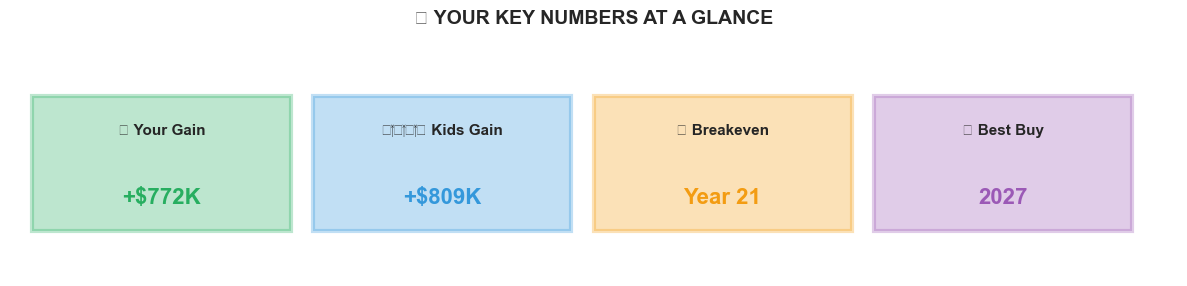


  ═══════════════════════════════════════════════════════════════════════════

  💝 REMEMBER: The goal isn't just numbers—it's FREEDOM and SECURITY
     for you and Terri now, and a meaningful legacy for your kids.

  🖨️  TIP: Print this page (Ctrl+P) for a handy reference!

  ═══════════════════════════════════════════════════════════════════════════



In [16]:
# =============================================================================
# 📋 CHAPTER 8: Quick Reference Card (Printable Summary)
# =============================================================================

# Get recommended scenario results
rec = project_scenario(175_000, 8, True, HOME_PURCHASE_YEAR, HOME_DOWN_PAYMENT)
no_act = project_scenario(0, 0, False, HOME_PURCHASE_YEAR, HOME_DOWN_PAYMENT)
rec_legacy = calc_legacy(rec)
no_legacy = calc_legacy(no_act)

print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║                                                                               ║
║           📋 CHAWLA FAMILY RETIREMENT QUICK REFERENCE CARD                    ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║""")
print(f"""║  👨 RAJESH: Age {SPOUSE1_AGE}                    👩 TERRI: Age {SPOUSE2_AGE}                       ║""")
print(f"""║                                                                               ║
║  💰 YOUR NUMBERS TODAY:                                                       ║
║  ───────────────────────────────────────────────────────────────────────────  ║
║  Total Wealth:          ${TOTAL_WEALTH:>12,}                                  ║
║  Pre-Tax IRAs:          ${TOTAL_PRETAX:>12,}  ({TOTAL_PRETAX/TOTAL_WEALTH:.0%})                            ║
║  Taxable Account:       ${JOINT_TAXABLE:>12,}                                  ║
║  Monthly Need:          ${MONTHLY_NEED:>12,}                                  ║
║  Cash Reserve:          ${CASH_RESERVE:>12,}                                  ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  📅 KEY DATES:                                                                ║
║  ───────────────────────────────────────────────────────────────────────────  ║
║  {2025 + YRS_TO_TERRI_SS}  Terri SS starts (+${SPOUSE2_SS_ANNUAL:,}/year)                               ║
║  {2025 + YRS_TO_RAJESH_SS}  Rajesh SS starts (+${SPOUSE1_SS_ANNUAL:,}/year)                              ║
║  {2025 + YRS_TO_TERRI_RMD}  Terri RMDs begin (age 73) ⚠️                                       ║
║  {2025 + YRS_TO_RAJESH_RMD}  Rajesh RMDs begin (age 73) ⚠️                                      ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  🎯 RECOMMENDED STRATEGY: AGGRESSIVE CONVERSION                               ║
║  ───────────────────────────────────────────────────────────────────────────  ║
║                                                                               ║
║  CONVERSION TARGETS:                                                          ║
║  • Year 1 (2025):  $150,000 - $175,000                                        ║
║  • Year 2 (2026):  $150,000 - $175,000                                        ║
║  • Year 3 (2027):  $100,000 - $150,000  🏠 (home purchase year)               ║
║  • Years 4-8:      $50,000 - $100,000 (as bracket space allows)               ║
║                                                                               ║
║  BRACKET TARGETS:                                                             ║
║  • Fill 24% bracket: up to $383,900 taxable income                            ║
║  • Push into 32%:    up to $487,450 (worth it for RMD savings!)               ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  🛑 STOP SIGNALS:                                                             ║
║  ───────────────────────────────────────────────────────────────────────────  ║
║  □ Taxable account < ${CASH_RESERVE + 50000:,}                                      ║
║  □ Health emergency requiring cash                                            ║
║  □ Tax laws change significantly                                              ║
║  □ You've converted enough (IRA < $1M)                                        ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  📊 EXPECTED OUTCOMES (25 Years):                                             ║
║  ───────────────────────────────────────────────────────────────────────────  ║""")
print(f"""║                          NO ACTION      →    WITH STRATEGY                   ║
║  Your Wealth:           ${no_act['after_tax']:>10,}      →    ${rec['after_tax']:>10,}   (+${rec['after_tax']-no_act['after_tax']:,})  ║
║  Kids Inherit:          ${no_legacy['kids_total']:>10,}      →    ${rec_legacy['kids_total']:>10,}   (+${rec_legacy['kids_total']-no_legacy['kids_total']:,})  ║
║  Tax Kids Pay:          ${no_legacy['tax_paid_by_kids']:>10,}      →    ${rec_legacy['tax_paid_by_kids']:>10,}   (-${no_legacy['tax_paid_by_kids']-rec_legacy['tax_paid_by_kids']:,})  ║""")
print(f"""║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  🏠 HOME PURCHASE PLAN (${HOME_DOWN_PAYMENT:,} down):                                  ║
║  ───────────────────────────────────────────────────────────────────────────  ║
║  Best timing: {HOME_PURCHASE_YEAR}                                                          ║
║  • Convert aggressively in 2025-{HOME_PURCHASE_YEAR-1}                                         ║
║  • Use taxable account for down payment                                       ║
║  • Continue smaller conversions after purchase                                ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  ✅ NEXT STEPS:                                                               ║
║  ───────────────────────────────────────────────────────────────────────────  ║
║  □ 1. Review with CPA/advisor by December 15, 2025                            ║
║  □ 2. Execute first conversion ($150K-175K) by December 31, 2025              ║
║  □ 3. Set aside $40K-50K for April 2026 tax payment                           ║
║  □ 4. Schedule January 2026 review to plan Year 2                             ║
║  □ 5. Re-evaluate annually as circumstances change                            ║
║                                                                               ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

# Create a simple visual summary
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')

# Key metrics boxes
metrics = [
    ('💰 Your Gain', f'+${(rec["after_tax"]-no_act["after_tax"])/1000:.0f}K', '#27ae60'),
    ('👨‍👩‍👧‍👦 Kids Gain', f'+${(rec_legacy["kids_total"]-no_legacy["kids_total"])/1000:.0f}K', '#3498db'),
    ('📅 Breakeven', 'Year 21', '#f39c12'),
    ('🏠 Best Buy', str(HOME_PURCHASE_YEAR), '#9b59b6'),
]

for i, (label, value, color) in enumerate(metrics):
    rect = plt.Rectangle((i*0.25, 0.2), 0.23, 0.6, facecolor=color, alpha=0.3, edgecolor=color, linewidth=3)
    ax.add_patch(rect)
    ax.text(i*0.25 + 0.115, 0.65, label, ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(i*0.25 + 0.115, 0.35, value, ha='center', va='center', fontsize=16, fontweight='bold', color=color)

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, 1)
ax.set_title('🎯 YOUR KEY NUMBERS AT A GLANCE', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("""
  ═══════════════════════════════════════════════════════════════════════════
  
  💝 REMEMBER: The goal isn't just numbers—it's FREEDOM and SECURITY
     for you and Terri now, and a meaningful legacy for your kids.
     
  🖨️  TIP: Print this page (Ctrl+P) for a handy reference!
  
  ═══════════════════════════════════════════════════════════════════════════
""")